# TFM 4.- MODELIZACIÓN

     m o-o l o-a l o
     molopezalonso@gmail.com
     Mónica López Alonso

En este notebook se desarrolla la fase de modelización del rating soberano.

Se parte de la base preparada en el Notebook 3, en la que las variables del año \(t\) se utilizan para predecir el rating correspondiente al año \(t+1\).

La muestra ya se encuentra dividida temporalmente en:

- **Entrenamiento:** 2000-2018.
- **Validación:** 2019-2021.
- **Test:** 2022-2024.

A partir de este punto se desarrollan dos ramas de preprocesamiento:

### Rama A — Modelos sensibles a la escala

Incluye modelos lineales, regularizados, KNN, SVM y redes neuronales.

En esta rama se aplicará el preprocesamiento necesario para este tipo de modelos:

- imputación de valores ausentes;
- transformaciones logarítmicas en las variables que lo requieran;
- tratamiento de valores extremos;
- codificación de variables categóricas;
- escalado de las variables numéricas;
- reducción de dimensionalidad mediante PCA, si resulta conveniente.

Todos los procedimientos que necesiten estimar parámetros se ajustarán únicamente con el conjunto de entrenamiento y posteriormente se aplicarán a validación y test.

### Rama B — Modelos basados en árboles

Incluye árboles de decisión, Random Forest, Extra Trees y modelos de boosting.

Estos modelos no necesitan que las variables estén estandarizadas ni que sigan distribuciones aproximadamente simétricas, por lo que su preprocesamiento será diferente.

Ambas ramas utilizarán exactamente las mismas observaciones de entrenamiento, validación y test para que la comparación entre modelos sea homogénea.

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)


MODEL_DATA_PATH = Path("data/model")

MODEL_FILE = (
    MODEL_DATA_PATH
    / "country_risk_model_ready_2000_2024.csv"
)


df = pd.read_csv(MODEL_FILE)


print("Dimensiones:", df.shape)
print("Países:", df["iso3"].nunique())
print("Periodo:", df["year"].min(), "-", df["year"].max())

Dimensiones: (3434, 108)
Países: 159
Periodo: 2000 - 2024


In [2]:
train = df[
    df["data_split"] == "train"
].copy()

validation = df[
    df["data_split"] == "validation"
].copy()

test = df[
    df["data_split"] == "test"
].copy()


print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (2497, 108)
Validation: (466, 108)
Test: (471, 108)


In [3]:
print(
    "Train:",
    train["year"].min(),
    "-",
    train["year"].max()
)

print(
    "Validation:",
    validation["year"].min(),
    "-",
    validation["year"].max()
)

print(
    "Test:",
    test["year"].min(),
    "-",
    test["year"].max()
)

Train: 2000 - 2018
Validation: 2019 - 2021
Test: 2022 - 2024


## Rama A — Preprocesamiento para modelos sensibles a la escala

Esta rama prepara los datos para modelos lineales y regularizados, KNN, SVM y redes neuronales.

El preprocesamiento se ajusta exclusivamente con el conjunto de entrenamiento y posteriormente se aplica, sin volver a estimar sus parámetros, sobre validación y test.

Se aplican las siguientes operaciones:

1. **Imputación**
   - Variables numéricas: mediana del conjunto de entrenamiento.
   - Variables binarias y categóricas: categoría o valor más frecuente.
   - Se incorporan indicadores de ausencia en las variables numéricas.

2. **Transformaciones logarítmicas**
   Se aplica \(\log(1+x)\) a determinadas variables positivas con una distribución fuertemente asimétrica:
   - PIB real per cápita.
   - PIB PPA.
   - PIB per cápita PPA.
   - Deuda soberana en situación de default.

3. **Tratamiento de valores extremos**
   Los valores extremos económicamente plausibles no se eliminan. Se utiliza `RobustScaler`, basado en medidas robustas de posición y dispersión, para reducir su influencia.

4. **Variables categóricas**
   `region` e `income_level` se transforman mediante one-hot encoding, eliminando una categoría de referencia.

5. **Escalado**
   Las variables numéricas continuas se escalan mediante `RobustScaler`.

La selección de variables, el análisis de multicolinealidad y la posible aplicación de PCA se realizarán después de este preprocesamiento.

In [4]:
# Columnas que no son predictoras

columns_to_exclude = [
    "iso3",
    "iso2",
    "country",
    "year",
    "economic_period",
    "rating_year",
    "target_year",
    "data_split",
    "target_available_t1",
    "head_of_government",
    "rating_score_mean_t",
    "number_of_ratings_t",
    "has_at_least_one_rating_t",
    "rating_available_t",
    "persistence_available",
    "rating_change_t1",

    "exchange_rate_lcu_per_usd",

    "external_debt_pct_gni",
    "external_debt_service_pct_exports",
    "external_debt_stocks_current_usd",
    "reserves_pct_external_debt",
    "short_term_debt_pct_reserves",
    "bank_npl_pct_gross_loans",
    "global_competitiveness_index",
    "battle_related_deaths",
    "armed_conflict_dummy",
    "log_battle_related_deaths"
]


# Eliminar también cualquier variable del futuro t+1

columns_to_exclude += [
    column
    for column in df.columns
    if column.endswith("_t1")
]


# Modelo 1: variables fundamentales

model_variables_fundamentals = [
    column
    for column in df.columns
    if column not in columns_to_exclude
]


# Modelo 2: fundamentales + rating actual

model_variables_rating = (
    model_variables_fundamentals
    +
    ["rating_score_mean_t"]
)


print(
    "Variables fundamentales:",
    len(model_variables_fundamentals)
)

print(
    "Fundamentales + rating:",
    len(model_variables_rating)
)

Variables fundamentales: 71
Fundamentales + rating: 72


In [5]:
# Variables categóricas

categorical_variables = [
    "region",
    "income_level"
]


# Variables numéricas

numeric_variables = [
    column
    for column in model_variables_fundamentals
    if column not in categorical_variables
]


# Detectar variables binarias

binary_variables = [
    column
    for column in numeric_variables
    if set(
        train[column]
        .dropna()
        .unique()
    ).issubset({0, 1})
]


# Variables que transformaremos con logaritmo

log_variables = [
    "gdp_per_capita_constant_2015_usd",
    "gdp_ppp_constant_2021_intl_usd",
    "gdp_per_capita_ppp_constant_2021_intl_usd",
    "sovereign_debt_in_default_usd_mn"
]


log_variables = [
    column
    for column in log_variables
    if column in numeric_variables
]


# Resto de variables continuas

continuous_variables = [
    column
    for column in numeric_variables
    if column not in binary_variables
    and column not in log_variables
]


print("Continuas:", len(continuous_variables))
print("Logarítmicas:", len(log_variables))
print("Binarias:", len(binary_variables))
print("Categóricas:", len(categorical_variables))

Continuas: 51
Logarítmicas: 4
Binarias: 14
Categóricas: 2


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    RobustScaler
)

In [7]:
# Variables con transformación logarítmica

log_pipeline = Pipeline([
    (
        "log",
        FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        RobustScaler()
    )
])


# Variables continuas

continuous_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        RobustScaler()
    )
])


# Variables binarias

binary_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    )
])


# Variables categóricas

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

`SimpleImputer(add_indicator=True)` permite conservar además información sobre qué valores estaban originalmente ausentes, y `OneHotEncoder` admite categorías nuevas en validación/test mediante `handle_unknown="ignore"`.

In [8]:
preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "log",
            log_pipeline,
            log_variables
        ),
        (
            "continuous",
            continuous_pipeline,
            continuous_variables
        ),
        (
            "binary",
            binary_pipeline,
            binary_variables
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_variables
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [9]:
# Variables explicativas

X_train = train[
    model_variables_fundamentals
]

X_validation = validation[
    model_variables_fundamentals
]

X_test = test[
    model_variables_fundamentals
]


# Variable objetivo

y_train = train[
    "rating_score_mean_t1"
]

y_validation = validation[
    "rating_score_mean_t1"
]

y_test = test[
    "rating_score_mean_t1"
]

In [10]:
# Ajustar el preprocesamiento únicamente con train

X_train_A = preprocessor_A.fit_transform(
    X_train
)


# Aplicar exactamente la misma transformación

X_validation_A = preprocessor_A.transform(
    X_validation
)

X_test_A = preprocessor_A.transform(
    X_test
)

Eso significa que las medianas, categorías, escalas, etc. se aprenden exclusivamente con 2000-2018. Validación y test solo reciben la transformación ya aprendida. Ese es también el procedimiento que muestran tus apuntes al ajustar el escalador sobre `X_train` y después utilizar `.transform()` sobre test.

In [11]:
feature_names_A = (
    preprocessor_A
    .get_feature_names_out()
)


X_train_A = pd.DataFrame(
    X_train_A,
    columns=feature_names_A,
    index=X_train.index
)

X_validation_A = pd.DataFrame(
    X_validation_A,
    columns=feature_names_A,
    index=X_validation.index
)

X_test_A = pd.DataFrame(
    X_test_A,
    columns=feature_names_A,
    index=X_test.index
)


print("Train:", X_train_A.shape)
print("Validation:", X_validation_A.shape)
print("Test:", X_test_A.shape)

print(
    "NaN después del preprocesamiento:",
    X_train_A.isna().sum().sum()
)

Train: (2497, 141)
Validation: (466, 141)
Test: (471, 141)
NaN después del preprocesamiento: 0


**Preprocesamiento aplicado en la Rama A**

La Rama A está destinada a los modelos más sensibles a la escala y a la distribución de las variables, como los modelos lineales y regularizados, KNN, SVM y redes neuronales.

Todo el preprocesamiento se ajusta utilizando exclusivamente el conjunto de entrenamiento. Los parámetros aprendidos se aplican posteriormente, sin volver a estimarlos, sobre los conjuntos de validación y test.

##### 1. Tratamiento de valores ausentes
Se aplican diferentes estrategias según el tipo de variable.

- **Variables numéricas continuas**: Los valores ausentes se sustituyen por la mediana calculada en el conjunto de entrenamiento. La mediana se utiliza por ser menos sensible que la media a distribuciones asimétricas y valores extremos.

Además, se incorporan indicadores de ausencia, que permiten al modelo conocer si el valor original estaba disponible o había sido imputado.

- **Variables binarias**: Los valores ausentes se sustituyen por el valor más frecuente en el conjunto de entrenamiento. También se incorporan indicadores de ausencia.

- **Variables categóricas**: Las categorías ausentes se sustituyen por la categoría más frecuente del conjunto de entrenamiento.

Por tanto, en ningún caso se utilizan valores de validación o test para calcular los valores de imputación.

##### 2. Transformaciones logarítmicas

Se utiliza la transformación:
$$
\log(1+x)
$$

mediante `np.log1p()` en variables positivas o no negativas con importantes diferencias de magnitud entre países.

Las variables transformadas son:

| Variable original | Variable utilizada por la Rama A |
|---|---|
| `gdp_per_capita_constant_2015_usd` | $\log(1+\text{PIB per cápita})$ |
| `gdp_ppp_constant_2021_intl_usd` | $\log(1+\text{PIB PPA})$ |
| `gdp_per_capita_ppp_constant_2021_intl_usd` | $\log(1+\text{PIB per cápita PPA})$ |
| `sovereign_debt_in_default_usd_mn` | $\log(1+\text{Deuda soberana en default})$ |

> La transformación reduce las enormes diferencias de escala existentes entre países y disminuye la asimetría de estas variables.

Las variables originales no se eliminan de la base de datos general. Sin embargo, dentro de la matriz utilizada por la Rama A son sustituidas por su versión logarítmica. Por tanto, el modelo no recibe simultáneamente la variable original y su transformación logarítmica.

La Rama B podrá seguir utilizando las variables originales, ya que los modelos basados en árboles no necesitan corregir la asimetría de la misma forma.

##### 3. Tratamiento de valores extremos
No se eliminan ni se recortan automáticamente los valores extremos.

En un problema de riesgo soberano, observaciones como una inflación extraordinariamente elevada, un gran déficit fiscal, una fuerte caída del PIB o una situación de default pueden representar precisamente los episodios que el modelo debe aprender a identificar.

En lugar de eliminar estos valores se utiliza `RobustScaler` para las variables numéricas continuas y las variables transformadas logarítmicamente.

**`RobustScaler`** utiliza medidas robustas, principalmente la mediana y el rango intercuartílico, por lo que el escalado resulta menos sensible a observaciones extremas que una estandarización basada en media y desviación típica.

Es importante señalar que RobustScaler no elimina ni limita los outliers; únicamente reduce su influencia sobre el escalado.

##### 4. Variables binarias

Las variables binarias se mantienen en su representación original (0/1).

No se aplica RobustScaler sobre estas variables, ya que su propia escala ya tiene una interpretación adecuada.

Cuando presentan valores ausentes, estos se imputan utilizando el valor más frecuente observado en entrenamiento y se añade un indicador de ausencia.

##### 5. Codificación de variables categóricas

Las variables categóricas incluidas son:

- `region`
- `income_level`

Se transforman mediante One-Hot Encoding.

Cada categoría se convierte en una variable binaria independiente. Se elimina una categoría de referencia mediante: `drop="first"` para evitar introducir una columna redundante.

Además: `handle_unknown="ignore"`permite que, si en validación o test aparece una categoría que no estaba presente en entrenamiento, el proceso pueda continuar sin producir un error.

Antes de realizar el One-Hot Encoding, los valores categóricos ausentes se sustituyen por la categoría más frecuente del conjunto de entrenamiento.

---
Los conjuntos de validación y test reciben exactamente las mismas transformaciones aprendidas durante el entrenamiento, evitando así fuga de información.

##### Alternativas metodológicas para análisis posteriores
La estrategia utilizada constituye la especificación principal de la Rama A, pero posteriormente pueden realizarse pruebas de robustez con otras alternativas.

- Imputación: Podrán compararse la imputación por mediana con métodos como KNN Imputer o imputación iterativa. También podría analizarse una imputación basada en la estructura temporal de cada país, siempre que se utilice exclusivamente información disponible hasta el momento de predicción y no se introduzca información futura.

- Transformaciones: Las transformaciones logarítmicas podrán compararse con métodos como Yeo-Johnson. También puede estudiarse mantener determinadas variables en su escala original si la transformación no mejora el comportamiento predictivo.

- Valores extremos: Como alternativa a RobustScaler, podrá estudiarse una winsorización basada exclusivamente en los límites obtenidos del conjunto de entrenamiento. Esta opción permitiría limitar observaciones extremas, aunque debe utilizarse con cautela para no eliminar información relevante asociada a episodios de crisis.

- Escalado: Puede compararse RobustScaler con StandardScaler o, en determinados modelos, MinMaxScaler.

- Variables categóricas: El One-Hot Encoding constituye la opción principal por su sencillez e interpretabilidad. Como análisis alternativo podrían utilizarse otras codificaciones, aunque cualquier método que utilice información de la variable objetivo deberá estimarse exclusivamente dentro del conjunto de entrenamiento para evitar fuga de información.

- Indicadores de valores ausentes: También podrá compararse el modelo actual, que incorpora indicadores de ausencia, con una especificación que únicamente impute los valores sin añadir estos indicadores.

Estas alternativas se dejan mencionadas para futuras alternativas

## Rama B — Preprocesamiento para modelos basados en árboles

Esta rama está destinada a modelos basados en árboles de decisión, como Decision Tree, Random Forest, Extra Trees y modelos de boosting.

A diferencia de la Rama A, no se aplican transformaciones logarítmicas ni escalado de las variables numéricas. Los modelos basados en árboles construyen reglas de decisión mediante puntos de corte sobre las variables, por lo que no necesitan que todas ellas se encuentren en una escala comparable.

Tampoco se modifican los valores extremos económicamente plausibles, ya que pueden contener información relevante sobre episodios de crisis.

El preprocesamiento aplicado es:

- **Variables numéricas continuas:** imputación mediante la mediana del conjunto de entrenamiento e incorporación de indicadores de ausencia.
- **Variables binarias:** imputación mediante el valor más frecuente e incorporación de indicadores de ausencia.
- **Variables categóricas:** los valores ausentes se mantienen como una categoría específica y posteriormente se aplica One-Hot Encoding.
- **Sin transformaciones logarítmicas.**
- **Sin escalado.**
- **Sin winsorización de la especificación principal.**

Todo el preprocesamiento se ajusta exclusivamente utilizando el conjunto de entrenamiento y posteriormente se aplica a validación y test.

In [12]:
# Variables categóricas

categorical_variables_B = [
    "region",
    "income_level"
]


# Variables numéricas

numeric_variables_B = [
    column
    for column in model_variables_fundamentals
    if column not in categorical_variables_B
]


# Variables binarias

binary_variables_B = [
    column
    for column in numeric_variables_B
    if set(
        train[column]
        .dropna()
        .unique()
    ).issubset({0, 1})
]


# Variables continuas

continuous_variables_B = [
    column
    for column in numeric_variables_B
    if column not in binary_variables_B
]


print(
    "Continuas:",
    len(continuous_variables_B)
)

print(
    "Binarias:",
    len(binary_variables_B)
)

print(
    "Categóricas:",
    len(categorical_variables_B)
)

Continuas: 55
Binarias: 14
Categóricas: 2


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [14]:
continuous_pipeline_B = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

In [15]:
binary_pipeline_B = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    )
])

In [16]:
categorical_pipeline_B = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [17]:
preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline_B,
            continuous_variables_B
        ),
        (
            "binary",
            binary_pipeline_B,
            binary_variables_B
        ),
        (
            "categorical",
            categorical_pipeline_B,
            categorical_variables_B
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [18]:
# Variables explicativas

X_train_B = train[
    model_variables_fundamentals
]

X_validation_B = validation[
    model_variables_fundamentals
]

X_test_B = test[
    model_variables_fundamentals
]


# Variable objetivo

y_train_B = train[
    "rating_score_mean_t1"
]

y_validation_B = validation[
    "rating_score_mean_t1"
]

y_test_B = test[
    "rating_score_mean_t1"
]

In [19]:
X_train_B = preprocessor_B.fit_transform(
    X_train_B
)

X_validation_B = preprocessor_B.transform(
    X_validation_B
)

X_test_B = preprocessor_B.transform(
    X_test_B
)

In [20]:
feature_names_B = (
    preprocessor_B
    .get_feature_names_out()
)


X_train_B = pd.DataFrame(
    X_train_B,
    columns=feature_names_B,
    index=train.index
)

X_validation_B = pd.DataFrame(
    X_validation_B,
    columns=feature_names_B,
    index=validation.index
)

X_test_B = pd.DataFrame(
    X_test_B,
    columns=feature_names_B,
    index=test.index
)


print(
    "Train:",
    X_train_B.shape
)

print(
    "Validation:",
    X_validation_B.shape
)

print(
    "Test:",
    X_test_B.shape
)

print(
    "NaN en train:",
    X_train_B.isna().sum().sum()
)

Train: (2497, 143)
Validation: (466, 143)
Test: (471, 143)
NaN en train: 0


## Modelos baseline

Antes de estimar los modelos de machine learning se establecen modelos de referencia sencillos que permitan evaluar si la mayor complejidad de los modelos posteriores produce realmente una mejora predictiva.

Se utilizan dos baselines:

### Baseline de la media

Se utiliza como predicción constante el rating medio observado en el conjunto de entrenamiento.

$$
\widehat{Rating}_{t+1}
=
\overline{Rating}_{train}
$$

Este modelo representa una referencia básica que ignora completamente las características económicas de cada país.

### Baseline de persistencia

El segundo baseline supone que el rating del próximo año será igual al rating observado actualmente:

$$
\widehat{Rating}_{t+1}
=
Rating_t
$$

Este baseline resulta especialmente relevante debido a la elevada persistencia temporal de las calificaciones crediticias soberanas.

Los modelos desarrollados posteriormente deberán mejorar estos resultados para demostrar que las variables económicas, fiscales, externas, institucionales y políticas aportan capacidad predictiva adicional.

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_model(y_true, y_pred):

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "R2": r2_score(
            y_true,
            y_pred
        )
    }

Nuestra métrica principal será **MAE**, porque tiene una interpretación muy sencilla en nuestra escala 0–100:

> un MAE de 4 significa que, de media, la predicción se desvía 4 puntos de rating.

RMSE penalizará más los errores grandes y $R^2$ lo utilizaremos como medida complementaria.

In [22]:
# Rating medio del conjunto de entrenamiento

train_rating_mean = y_train.mean()


# Predicción constante para validación

baseline_mean_pred = np.full(
    len(y_validation),
    train_rating_mean
)


baseline_mean_results = evaluate_model(
    y_validation,
    baseline_mean_pred
)


baseline_mean_results

{'MAE': 25.272281673630673,
 'RMSE': np.float64(28.7581020745158),
 'R2': -0.06803429876962697}

In [23]:
# Observaciones con rating actual disponible

validation_persistence = validation[
    validation["rating_score_mean_t"].notna()
].copy()


y_validation_persistence = (
    validation_persistence[
        "rating_score_mean_t1"
    ]
)


persistence_pred = (
    validation_persistence[
        "rating_score_mean_t"
    ]
)


baseline_persistence_results = evaluate_model(
    y_validation_persistence,
    persistence_pred
)


baseline_persistence_results

{'MAE': 1.5050287356321843,
 'RMSE': np.float64(4.209193891755381),
 'R2': 0.9771042698066347}

In [24]:
baseline_results = pd.DataFrame([
    {
        "model": "Mean baseline",
        **baseline_mean_results
    },
    {
        "model": "Persistence baseline",
        **baseline_persistence_results
    }
])


display(
    baseline_results.round(3)
)

,model,MAE,RMSE,R2
0,Mean baseline,25.272,28.758,-0.068
1,Persistence baseline,1.505,4.209,0.977


El resultado es muy interesante porque  marca claramente el nivel de dificultad del problema.

El Mean baseline funciona muy mal:
-`MAE = 25.272`: de media se equivoca en unos 25 puntos de rating.
- `RMSE = 28.758`: los errores grandes son frecuentes.
- `R² = -0.068`: es peor que predecir simplemente con una media bien ajustada al conjunto evaluado.

Eso era esperable: predecir el mismo rating medio para todos los países ignora completamente las diferencias entre economías.

En cambio, el Persistence baseline es muchísimo mejor:
- `MAE = 1.505`: de media se equivoca solo en 1,5 puntos de rating.
-`RMSE = 4.209`: aunque normalmente acierta bastante, existen algunos cambios de rating más fuertes que elevan el RMSE.
- `R² = 0.977`: explica aproximadamente el 97,7 % de la variabilidad del rating del año siguiente.

Esto nos dice algo muy importante:

> El rating soberano presenta una persistencia temporal extremadamente alta.

Es decir, en la mayoría de los casos:
$$
Rating_{t+1} ≈ Rating_t
$$

Por tanto, el reto real de nuestros modelos no es simplemente predecir bien el rating futuro, porque repetir el rating actual ya lo hace extraordinariamente bien.

El reto será comprobar si las variables macroeconómicas, fiscales, externas, institucionales y políticas permiten mejorar ese MAE de 1,505, especialmente cuando se producen cambios de rating.

Y esto justifica perfectamente que tengamos los dos modelos que hemos planteado:
$$
Fundamentales_t → Rating_{t+1} 
$$

para comprobar cuánto podemos predecir sin conocer el rating actual,

y:
$$
Fundamentales_t + Rating_{t} → Rating_{t+1} 
$$

para comprobar si las variables económicas aportan información adicional sobre la simple persistencia.

Además, se añadira luego una evaluación específica sobre los años en los que sí cambia el rating, porque un modelo que prediga siempre “se queda igual” puede tener métricas globales excelentes pero fallar precisamente en lo que más nos interesa: anticipar upgrades y downgrades.


> Los resultados muestran una elevada persistencia de las calificaciones soberanas. El baseline basado en la media presenta una capacidad predictiva muy limitada, con un MAE de 25,27 puntos y un $R^2$
 negativo. En cambio, el baseline de persistencia, que utiliza el rating del año actual como predicción del año siguiente, obtiene un MAE de tan solo 1,51 puntos y un $R^2$ de 0,977. Esto indica que las calificaciones crediticias cambian con poca frecuencia y que el rating actual constituye un predictor extremadamente potente del rating futuro. En consecuencia, los modelos posteriores deberán evaluarse no solo por su capacidad para mejorar estas métricas globales, sino también por su capacidad para anticipar correctamente los cambios de rating.

In [25]:
# Comprobar el tamaño de la muestra comparable con el baseline de persistencia

validation_common = validation[
    validation["rating_score_mean_t"].notna()
].copy()

common_validation_index = validation_common.index

print(
    "Validación completa:",
    len(validation)
)

print(
    "Validación comparable con persistencia:",
    len(validation_common)
)

Validación completa: 466
Validación comparable con persistencia: 464


### 1. REGRESIÓN LINEAL MULTIPLE
> Primer modelo real perteneciente a la RAMA A

Como primer modelo supervisado se estima una regresión lineal múltiple utilizando exclusivamente las variables fundamentales.

El modelo se ajusta con las observaciones del periodo de entrenamiento 2000-2018 y se evalúa inicialmente sobre el periodo de validación 2019-2021.

Las variables explicativas han sido previamente imputadas, transformadas, codificadas y escaladas utilizando únicamente información del conjunto de entrenamiento.

In [26]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_A,
    y_train
)

linear_validation_pred = linear_model.predict(
    X_validation_A
)

linear_results = evaluate_model(
    y_validation,
    linear_validation_pred
)

linear_results

{'MAE': 7.260608698821887,
 'RMSE': np.float64(10.456482821612624),
 'R2': 0.8587995714890702}

In [28]:
# Predicciones de la regresión con su índice original

linear_validation_pred_series = pd.Series(
    linear_validation_pred,
    index=validation.index
)

# Seleccionar las 464 observaciones comparables

linear_common_pred = (
    linear_validation_pred_series
    .loc[common_validation_index]
)

# Baseline de la media en la misma muestra

mean_common_pred = np.full(
    len(validation_common),
    train_rating_mean
)

# Resultados sobre exactamente la misma muestra

comparison_linear = pd.DataFrame({
    "Media": evaluate_model(
        validation_common["rating_score_mean_t1"],
        mean_common_pred
    ),
    "Persistencia": evaluate_model(
        validation_common["rating_score_mean_t1"],
        validation_common["rating_score_mean_t"]
    ),
    "Regresión lineal": evaluate_model(
        validation_common["rating_score_mean_t1"],
        linear_common_pred
    )
}).T

display(
    comparison_linear.round(3)
)

,MAE,RMSE,R2
Media,25.223,28.717,-0.066
Persistencia,1.505,4.209,0.977
Regresión lineal,7.241,10.442,0.859


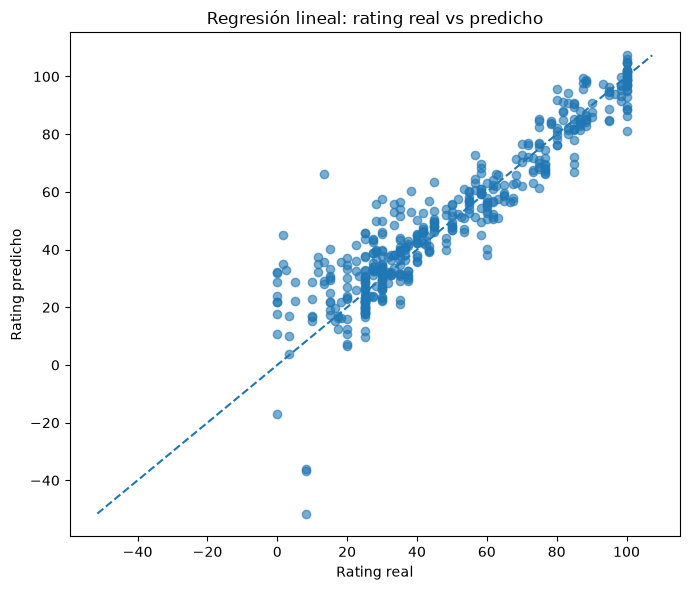

In [31]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_validation,
    linear_validation_pred,
    alpha=0.6
)

min_value = min(
    y_validation.min(),
    linear_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    linear_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")
plt.title("Regresión lineal: rating real vs predicho")

plt.tight_layout()
plt.show()

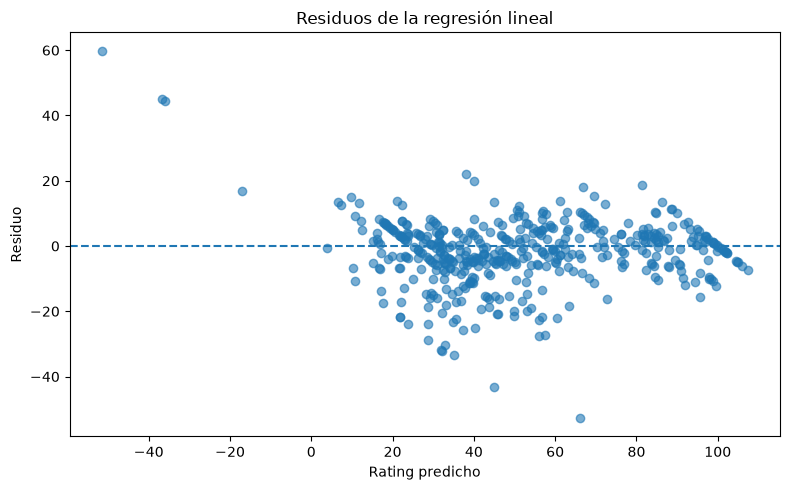

In [32]:
linear_residuals = (
    y_validation.values
    - linear_validation_pred
)

plt.figure(figsize=(8, 5))

plt.scatter(
    linear_validation_pred,
    linear_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Rating predicho")
plt.ylabel("Residuo")
plt.title("Residuos de la regresión lineal")

plt.tight_layout()
plt.show()

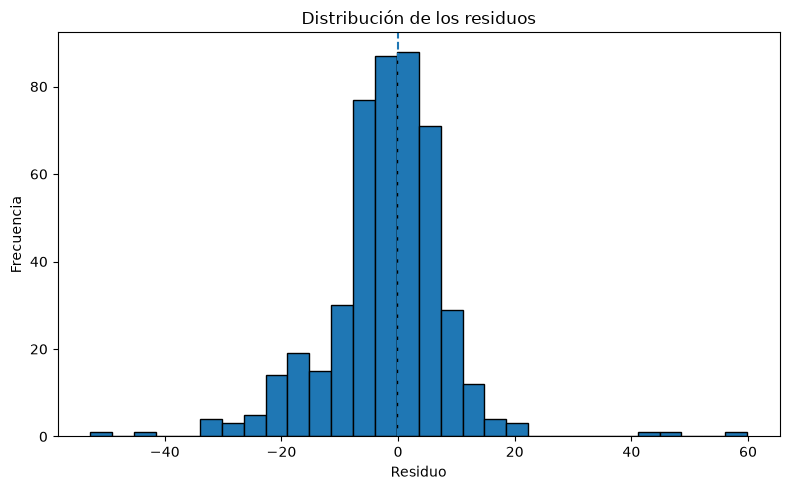

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(
    linear_residuals,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")

plt.tight_layout()
plt.show()

In [34]:
linear_validation_results = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

linear_validation_results[
    "prediction"
] = linear_validation_pred

linear_validation_results[
    "absolute_error"
] = abs(
    linear_validation_results["rating_score_mean_t1"]
    - linear_validation_results["prediction"]
)

linear_error_by_year = (
    linear_validation_results
    .groupby("year")["absolute_error"]
    .mean()
)

display(
    linear_error_by_year
)

year
2019    7.128032
2020    6.763482
2021    7.886276
Name: absolute_error, dtype: float64

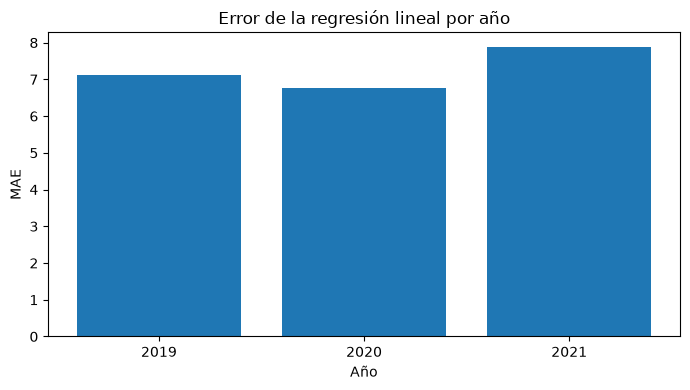

In [35]:
plt.figure(figsize=(7, 4))

plt.bar(
    linear_error_by_year.index.astype(str),
    linear_error_by_year.values
)

plt.xlabel("Año")
plt.ylabel("MAE")
plt.title("Error de la regresión lineal por año")

plt.tight_layout()
plt.show()

In [36]:
worst_linear_predictions = (
    linear_validation_results
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_linear_predictions[
        [
            "country",
            "year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_score_mean_t1,prediction,absolute_error
3379,"Venezuela, RB",2020,8.33,-51.52,59.85
2782,Russian Federation,2021,13.33,66.07,52.74
3380,"Venezuela, RB",2021,8.33,-36.72,45.05
3378,"Venezuela, RB",2019,8.33,-36.07,44.41
409,Belarus,2021,1.67,44.89,43.22
1908,Sri Lanka,2021,1.67,35.04,33.37
2657,Puerto Rico (US),2021,0.00,32.28,32.28
2655,Puerto Rico (US),2019,0.00,31.82,31.82
1229,Ghana,2021,2.50,32.96,30.46
2656,Puerto Rico (US),2020,0.00,28.76,28.76


Los resultados muestran que la regresión lineal basada exclusivamente en variables fundamentales presenta una elevada capacidad explicativa, con un ($R^2$) de 0,859 en el periodo de validación. El gráfico entre valores reales y predichos muestra una clara concentración de las observaciones alrededor de la diagonal, especialmente para los países con calificaciones medias y elevadas.

No obstante, el análisis de los residuos revela limitaciones relevantes. Los mayores errores se concentran principalmente en países con calificaciones crediticias reducidas y en episodios asociados a acontecimientos económicos o geopolíticos extraordinarios. Además, al no estar acotada la regresión lineal, se obtienen ocasionalmente predicciones fuera de la escala teórica 0-100, incluyendo valores negativos, lo que constituye una limitación adicional del modelo.

La distribución de los residuos se encuentra concentrada alrededor de cero, aunque presenta colas pronunciadas debido a un número reducido de observaciones con errores elevados. Asimismo, el error medio absoluto aumenta de 6,76 puntos en 2020 a 7,89 puntos en 2021. Debe tenerse en cuenta que las variables correspondientes a 2021 se utilizan para predecir la calificación de 2022. Entre las observaciones con mayores errores durante este periodo aparecen Rusia, Bielorrusia, Ucrania y Sri Lanka, entre otros casos, lo que pone de manifiesto la dificultad de un modelo basado únicamente en fundamentales observados en (t) para anticipar shocks extraordinarios producidos durante (t+1).

En conjunto, los resultados indican que los fundamentales económicos, fiscales, externos e institucionales contienen una cantidad importante de información sobre el nivel de calidad crediticia de los países, aunque una relación estrictamente lineal resulta insuficiente para capturar determinadas situaciones extremas y cambios bruscos de calificación.


In [37]:
# Predicciones fuera de la escala 0-100

outside_scale = (
    (linear_validation_pred < 0)
    |
    (linear_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_scale.sum()
)

print(
    "Porcentaje:",
    round(
        outside_scale.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    linear_validation_pred.min()
)

print(
    "Predicción máxima:",
    linear_validation_pred.max()
)

Predicciones fuera de 0-100: 17
Porcentaje: 3.65 %
Predicción mínima: -51.51632815854782
Predicción máxima: 107.36423356180897


In [38]:
linear_validation_results[
    "rating_year"
] = (
    linear_validation_results["year"] + 1
)

display(
    linear_validation_results
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ]
    .round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
3379,"Venezuela, RB",2020,2021,8.33,-51.52,59.85
2782,Russian Federation,2021,2022,13.33,66.07,52.74
3380,"Venezuela, RB",2021,2022,8.33,-36.72,45.05
3378,"Venezuela, RB",2019,2020,8.33,-36.07,44.41
409,Belarus,2021,2022,1.67,44.89,43.22
1908,Sri Lanka,2021,2022,1.67,35.04,33.37
2657,Puerto Rico (US),2021,2022,0.00,32.28,32.28
2655,Puerto Rico (US),2019,2020,0.00,31.82,31.82
1229,Ghana,2021,2022,2.50,32.96,30.46
2656,Puerto Rico (US),2020,2021,0.00,28.76,28.76


La regresión lineal genera 17 predicciones fuera del intervalo teórico 0-100, equivalentes al 3,65 % de las observaciones del conjunto de validación. La predicción mínima alcanza -51,52 puntos y la máxima 107,36.

Este comportamiento constituye una limitación propia de la regresión lineal, ya que el modelo no impone restricciones sobre el rango de la variable dependiente. Aunque la mayoría de las predicciones permanecen dentro de la escala válida, los casos extremos muestran que el modelo puede producir resultados económicamente difíciles de interpretar, especialmente para países con niveles de riesgo muy elevados.


In [39]:
linear_coefficients = pd.DataFrame({
    "variable": X_train_A.columns,
    "coefficient": linear_model.coef_
})

linear_coefficients[
    "absolute_coefficient"
] = (
    linear_coefficients["coefficient"].abs()
)

linear_coefficients = (
    linear_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    linear_coefficients.head(30)
)

,variable,coefficient,absolute_coefficient
0,government_expenditure_pct_gdp,62.875723,62.875723
1,government_revenue_pct_gdp,-56.010044,56.010044
2,missingindicator_rule_of_law_estimate,-29.575129,29.575129
3,missingindicator_government_revenue_pct_gdp,22.803946,22.803946
4,gdp_per_capita_constant_2015_usd,20.952375,20.952375
5,regulatory_quality_estimate,18.124979,18.124979
6,missingindicator_government_revenue_3y_mean,-17.612699,17.612699
7,fiscal_balance_pct_gdp,16.828493,16.828493
8,missingindicator_gdp_per_capita_constant_2015_usd,16.733287,16.733287
9,government_expenditure_3y_mean,-14.349437,14.349437


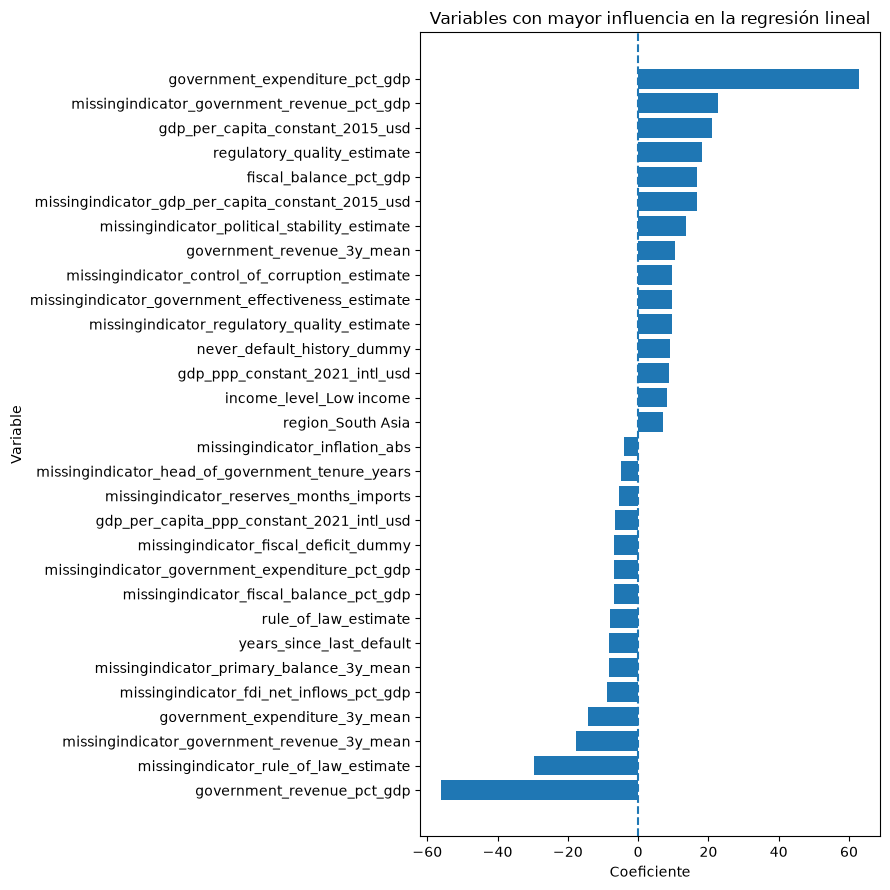

In [41]:
top_coefficients_plot = pd.concat(
    [
        top_negative,
        top_positive
    ]
).sort_values(
    "coefficient"
)

plt.figure(
    figsize=(9, 9)
)

plt.barh(
    top_coefficients_plot["variable"],
    top_coefficients_plot["coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title(
    "Variables con mayor influencia en la regresión lineal"
)

plt.tight_layout()
plt.show()

In [45]:
import statsmodels.api as sm

# Matriz de entrenamiento con constante
X_train_stats = sm.add_constant(
    X_train_A,
    has_constant="add"
)

# País correspondiente a cada observación de entrenamiento
train_groups = train.loc[
    X_train_A.index,
    "iso3"
]

# Regresión OLS con errores estándar agrupados por país
linear_stats_model = sm.OLS(
    y_train,
    X_train_stats
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train_groups
    }
)

print(
    linear_stats_model.summary()
)

                             OLS Regression Results                             
Dep. Variable:     rating_score_mean_t1   R-squared:                       0.922
Model:                              OLS   Adj. R-squared:                  0.918
Method:                   Least Squares   F-statistic:                 6.716e+07
Date:                  Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                          00:18:55   Log-Likelihood:                -8553.5
No. Observations:                  2497   AIC:                         1.734e+04
Df Residuals:                      2379   BIC:                         1.803e+04
Df Model:                           117                                         
Covariance Type:                cluster                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

C:\Users\pedro.lopez\AppData\Local\anaconda3\envs\tfm_env\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 141, but rank is 112
  warnings.warn('covariance of constraints does not have full '


In [46]:
linear_significance = pd.DataFrame({
    "variable": linear_stats_model.params.index,
    "coefficient": linear_stats_model.params.values,
    "std_error": linear_stats_model.bse.values,
    "t_value": linear_stats_model.tvalues.values,
    "p_value": linear_stats_model.pvalues.values,
    "ci_lower": linear_stats_model.conf_int()[0].values,
    "ci_upper": linear_stats_model.conf_int()[1].values
})

# Quitamos la constante de la tabla de variables
linear_significance = linear_significance[
    linear_significance["variable"] != "const"
].copy()

# Significancia
linear_significance["significant_5pct"] = (
    linear_significance["p_value"] < 0.05
)

linear_significance["absolute_coefficient"] = (
    linear_significance["coefficient"].abs()
)

linear_significance = linear_significance.sort_values(
    "p_value"
).reset_index(drop=True)

display(
    linear_significance.head(30).round(4)
)

,variable,coefficient,std_error,t_value,p_value,ci_lower,ci_upper,significant_5pct,absolute_coefficient
0,gdp_ppp_constant_2021_intl_usd,8.7732,0.9755,8.9938,0.0000,6.8613,10.6851,True,8.7732
1,regulatory_quality_estimate,18.1250,2.4634,7.3576,0.0000,13.2968,22.9532,True,18.1250
2,government_debt_pct_gdp,-3.5379,0.5904,-5.9927,0.0000,-4.6950,-2.3808,True,3.5379
3,missingindicator_fragile_states_index,4.6283,0.8557,5.4089,0.0000,2.9512,6.3054,True,4.6283
4,gdp_per_capita_constant_2015_usd,20.9524,4.0530,5.1695,0.0000,13.0086,28.8962,True,20.9524
5,trade_openness_pct_gdp,-0.9844,0.1937,-5.0827,0.0000,-1.3640,-0.6048,True,0.9844
6,sovereign_debt_in_default_usd_mn,-2.7355,0.6200,-4.4120,0.0000,-3.9508,-1.5203,True,2.7355
7,fragile_states_index,-2.0743,0.4774,-4.3447,0.0000,-3.0101,-1.1386,True,2.0743
8,reserves_months_imports,1.1170,0.2727,4.0963,0.0000,0.5826,1.6515,True,1.1170
9,missingindicator_rule_of_law_estimate,-29.5751,7.4225,-3.9845,0.0001,-44.1230,-15.0273,True,29.5751


In [47]:
def significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return ""

linear_significance["significance"] = (
    linear_significance["p_value"]
    .apply(significance_stars)
)

display(
    linear_significance[
        [
            "variable",
            "coefficient",
            "std_error",
            "t_value",
            "p_value",
            "significance"
        ]
    ]
    .head(30)
    .round(4)
)

,variable,coefficient,std_error,t_value,p_value,significance
0,gdp_ppp_constant_2021_intl_usd,8.7732,0.9755,8.9938,0.0000,***
1,regulatory_quality_estimate,18.1250,2.4634,7.3576,0.0000,***
2,government_debt_pct_gdp,-3.5379,0.5904,-5.9927,0.0000,***
3,missingindicator_fragile_states_index,4.6283,0.8557,5.4089,0.0000,***
4,gdp_per_capita_constant_2015_usd,20.9524,4.0530,5.1695,0.0000,***
5,trade_openness_pct_gdp,-0.9844,0.1937,-5.0827,0.0000,***
6,sovereign_debt_in_default_usd_mn,-2.7355,0.6200,-4.4120,0.0000,***
7,fragile_states_index,-2.0743,0.4774,-4.3447,0.0000,***
8,reserves_months_imports,1.1170,0.2727,4.0963,0.0000,***
9,missingindicator_rule_of_law_estimate,-29.5751,7.4225,-3.9845,0.0001,***


In [48]:
print(
    "Variables significativas al 5 %:",
    (linear_significance["p_value"] < 0.05).sum()
)

print(
    "Variables significativas al 1 %:",
    (linear_significance["p_value"] < 0.01).sum()
)

print(
    "Variables significativas al 0,1 %:",
    (linear_significance["p_value"] < 0.001).sum()
)

Variables significativas al 5 %: 55
Variables significativas al 1 %: 34
Variables significativas al 0,1 %: 16


Preliminarmente aparecen 55 coeficientes con p<0.05, pero la matriz presenta problemas importantes de multicolinealidad, por lo que la significancia individual debe revisarse antes de interpretar los coeficientes.

In [54]:
# Detectar columnas exactamente duplicadas en entrenamiento

duplicate_mask = X_train_A.T.duplicated()

duplicate_columns_to_drop = (
    X_train_A.columns[duplicate_mask]
    .tolist()
)

print(
    "Columnas duplicadas que se eliminarán:",
    len(duplicate_columns_to_drop)
)

display(
    pd.DataFrame({
        "variable_eliminada": duplicate_columns_to_drop
    })
)

Columnas duplicadas que se eliminarán: 23


,variable_eliminada
0,missingindicator_gdp_per_capita_ppp_constant_2...
1,missingindicator_government_expenditure_pct_gdp
2,missingindicator_net_interest_payments_pct_gdp
3,missingindicator_imports_pct_gdp
4,missingindicator_trade_openness_pct_gdp
5,missingindicator_government_effectiveness_esti...
6,missingindicator_regulatory_quality_estimate
7,missingindicator_government_changes_previous_5y
8,missingindicator_gdp_growth_3y_std
9,missingindicator_inflation_abs


In [55]:
X_train_A_reduced = X_train_A.drop(
    columns=duplicate_columns_to_drop
)

X_validation_A_reduced = X_validation_A.drop(
    columns=duplicate_columns_to_drop
)

X_test_A_reduced = X_test_A.drop(
    columns=duplicate_columns_to_drop
)

print(
    "Variables originales:",
    X_train_A.shape[1]
)

print(
    "Variables después de eliminar duplicados:",
    X_train_A_reduced.shape[1]
)

Variables originales: 141
Variables después de eliminar duplicados: 118


In [56]:
print(
    "Columnas duplicadas restantes:",
    X_train_A_reduced.T.duplicated().sum()
)

Columnas duplicadas restantes: 0


In [57]:
X_vif = sm.add_constant(
    X_train_A_reduced,
    has_constant="add"
)

vif_results = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_results = (
    vif_results[
        vif_results["variable"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    vif_results.head(50)
)

C:\Users\pedro.lopez\AppData\Local\anaconda3\envs\tfm_env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\pedro.lopez\AppData\Local\anaconda3\envs\tfm_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF
0,imports_pct_gdp,inf
1,exports_pct_gdp,inf
2,trade_openness_pct_gdp,inf
3,missingindicator_exports_pct_gdp,inf
4,government_revenue_pct_gdp,7.811429e+04
5,government_expenditure_pct_gdp,7.019134e+04
6,fiscal_balance_pct_gdp,1.772703e+04
7,government_revenue_3y_mean,6.618959e+03
8,government_expenditure_3y_mean,6.006990e+03
9,fiscal_balance_3y_mean,1.329337e+03


In [58]:
print(
    "VIF infinito:",
    np.isinf(vif_results["VIF"]).sum()
)

print(
    "VIF >= 10:",
    (vif_results["VIF"] >= 10).sum()
)

print(
    "VIF entre 5 y 10:",
    (
        (vif_results["VIF"] >= 5)
        &
        (vif_results["VIF"] < 10)
    ).sum()
)

VIF infinito: 4
VIF >= 10: 56
VIF entre 5 y 10: 14


In [59]:
# Variables con VIF infinito

vif_infinite = vif_results[
    np.isinf(vif_results["VIF"])
].copy()

display(vif_infinite)

,variable,VIF
0,imports_pct_gdp,inf
1,exports_pct_gdp,inf
2,trade_openness_pct_gdp,inf
3,missingindicator_exports_pct_gdp,inf


In [62]:
variable_to_drop = "trade_openness_pct_gdp"

X_train_A_reduced = X_train_A_reduced.drop(
    columns=[variable_to_drop]
)

X_validation_A_reduced = X_validation_A_reduced.drop(
    columns=[variable_to_drop]
)

X_test_A_reduced = X_test_A_reduced.drop(
    columns=[variable_to_drop]
)

print(
    "Número de variables:",
    X_train_A_reduced.shape[1]
)

Número de variables: 117


In [60]:
# Variables con VIF elevado

high_vif = vif_results[
    (vif_results["VIF"] >= 10)
    &
    (~np.isinf(vif_results["VIF"]))
].copy()

display(
    high_vif.head(30)
)

,variable,VIF
4,government_revenue_pct_gdp,78114.291074
5,government_expenditure_pct_gdp,70191.335103
6,fiscal_balance_pct_gdp,17727.028538
7,government_revenue_3y_mean,6618.958828
8,government_expenditure_3y_mean,6006.990304
9,fiscal_balance_3y_mean,1329.337120
10,missingindicator_fiscal_balance_pct_gdp,568.230082
11,missingindicator_fiscal_balance_3y_mean,437.281817
12,missingindicator_government_revenue_pct_gdp,418.350676
13,missingindicator_government_revenue_3y_mean,387.001270


In [64]:
# Variables redundantes por relaciones contables

redundant_variables = [
    "government_revenue_pct_gdp",
    "government_revenue_3y_mean",
    "net_interest_payments_pct_gdp",
    "saving_investment_gap"
]

# Eliminar también sus indicadores de ausencia si existen

redundant_missing_indicators = [
    f"missingindicator_{variable}"
    for variable in redundant_variables
]

variables_to_drop = [
    variable
    for variable in (
        redundant_variables
        + redundant_missing_indicators
    )
    if variable in X_train_A_reduced.columns
]

print(
    "Variables eliminadas:"
)

for variable in variables_to_drop:
    print(variable)

X_train_A_reduced = X_train_A_reduced.drop(
    columns=variables_to_drop
)

X_validation_A_reduced = X_validation_A_reduced.drop(
    columns=variables_to_drop
)

X_test_A_reduced = X_test_A_reduced.drop(
    columns=variables_to_drop
)

Variables eliminadas:
government_revenue_pct_gdp
government_revenue_3y_mean
net_interest_payments_pct_gdp
saving_investment_gap
missingindicator_government_revenue_pct_gdp
missingindicator_government_revenue_3y_mean


In [66]:
# Versión específica para la regresión OLS interpretable

missing_indicator_columns = [
    column
    for column in X_train_A_reduced.columns
    if column.startswith("missingindicator_")
]

X_train_OLS = X_train_A_reduced.drop(
    columns=missing_indicator_columns
)

X_validation_OLS = X_validation_A_reduced.drop(
    columns=missing_indicator_columns
)

print(
    "Indicadores de ausencia eliminados:",
    len(missing_indicator_columns)
)

print(
    "Variables restantes:",
    X_train_OLS.shape[1]
)

Indicadores de ausencia eliminados: 38
Variables restantes: 73


In [67]:
X_train_OLS = X_train_OLS.drop(
    columns=["inflation_abs"]
)

X_validation_OLS = X_validation_OLS.drop(
    columns=["inflation_abs"]
)

In [68]:
fiscal_vif_variables = [
    "fiscal_balance_pct_gdp",
    "fiscal_balance_3y_mean",
    "primary_balance_pct_gdp",
    "primary_balance_3y_mean"
]

display(
    X_train_OLS[
        fiscal_vif_variables
    ].corr().round(3)
)

,fiscal_balance_pct_gdp,fiscal_balance_3y_mean,primary_balance_pct_gdp,primary_balance_3y_mean
fiscal_balance_pct_gdp,1.000,0.841,0.908,0.769
fiscal_balance_3y_mean,0.841,1.000,0.707,0.899
primary_balance_pct_gdp,0.908,0.707,1.000,0.808
primary_balance_3y_mean,0.769,0.899,0.808,1.000


In [70]:
fiscal_variables_to_drop = [
    "fiscal_balance_3y_mean",
    "primary_balance_3y_mean"
]

X_train_OLS = X_train_OLS.drop(
    columns=fiscal_variables_to_drop
)

X_validation_OLS = X_validation_OLS.drop(
    columns=fiscal_variables_to_drop
)

In [72]:
ols_variables_to_drop = [
    "years_since_last_default",
    "gdp_per_capita_constant_2015_usd",
    "government_expenditure_3y_mean",
    "primary_balance_pct_gdp"
]

X_train_OLS = X_train_OLS.drop(
    columns=ols_variables_to_drop
)

X_validation_OLS = X_validation_OLS.drop(
    columns=ols_variables_to_drop
)

print(
    "Variables restantes:",
    X_train_OLS.shape[1]
)

Variables restantes: 66


In [73]:
wgi_variables = [
    "control_of_corruption_estimate",
    "government_effectiveness_estimate",
    "political_stability_estimate",
    "regulatory_quality_estimate",
    "rule_of_law_estimate",
    "voice_accountability_estimate"
]

display(
    X_train_OLS[
        wgi_variables
    ].corr().round(3)
)

,control_of_corruption_estimate,government_effectiveness_estimate,political_stability_estimate,regulatory_quality_estimate,rule_of_law_estimate,voice_accountability_estimate
control_of_corruption_estimate,1.000,0.938,0.780,0.892,0.946,0.794
government_effectiveness_estimate,0.938,1.000,0.729,0.928,0.934,0.780
political_stability_estimate,0.780,0.729,1.000,0.712,0.793,0.695
regulatory_quality_estimate,0.892,0.928,0.712,1.000,0.927,0.804
rule_of_law_estimate,0.946,0.934,0.793,0.927,1.000,0.859
voice_accountability_estimate,0.794,0.780,0.695,0.804,0.859,1.000


In [75]:
wgi_variables_to_drop = [
    "rule_of_law_estimate",
    "control_of_corruption_estimate",
    "regulatory_quality_estimate",
    "voice_accountability_estimate"
]

X_train_OLS = X_train_OLS.drop(
    columns=wgi_variables_to_drop
)

X_validation_OLS = X_validation_OLS.drop(
    columns=wgi_variables_to_drop
)

In [77]:
external_variables = [
    "exports_pct_gdp",
    "imports_pct_gdp",
    "current_account_balance_pct_gdp",
    "current_account_3y_mean"
]

display(
    X_train_OLS[
        external_variables
    ].corr().round(3)
)

,exports_pct_gdp,imports_pct_gdp,current_account_balance_pct_gdp,current_account_3y_mean
exports_pct_gdp,1.000,0.890,0.323,0.310
imports_pct_gdp,0.890,1.000,-0.002,0.015
current_account_balance_pct_gdp,0.323,-0.002,1.000,0.881
current_account_3y_mean,0.310,0.015,0.881,1.000


In [78]:
X_train_OLS = X_train_OLS.drop(
    columns=["current_account_3y_mean"]
)

X_validation_OLS = X_validation_OLS.drop(
    columns=["current_account_3y_mean"]
)

In [80]:
X_train_OLS = X_train_OLS.drop(
    columns=["imports_pct_gdp"]
)

X_validation_OLS = X_validation_OLS.drop(
    columns=["imports_pct_gdp"]
)

In [81]:
income_level_columns = [
    column
    for column in X_train_OLS.columns
    if column.startswith("income_level_")
]

print(
    "Dummies de renta eliminadas:",
    income_level_columns
)

X_train_OLS = X_train_OLS.drop(
    columns=income_level_columns
)

X_validation_OLS = X_validation_OLS.drop(
    columns=income_level_columns
)

Dummies de renta eliminadas: ['income_level_Low income', 'income_level_Lower middle income', 'income_level_Upper middle income']


In [85]:
X_vif_OLS = sm.add_constant(
    X_train_OLS,
    has_constant="add"
)

vif_OLS = pd.DataFrame({
    "variable": X_vif_OLS.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_OLS.values,
            i
        )
        for i in range(X_vif_OLS.shape[1])
    ]
})

vif_OLS = (
    vif_OLS[
        vif_OLS["variable"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "VIF máximo:",
    vif_OLS["VIF"].max()
)

print(
    "VIF >= 10:",
    (vif_OLS["VIF"] >= 10).sum()
)

print(
    "VIF entre 5 y 10:",
    (
        (vif_OLS["VIF"] >= 5)
        &
        (vif_OLS["VIF"] < 10)
    ).sum()
)

display(
    vif_OLS.head(20)
)

VIF máximo: 7.019534431714054
VIF >= 10: 0
VIF entre 5 y 10: 4


,variable,VIF
0,default_previous_10y,7.019534
1,gdp_per_capita_ppp_constant_2021_intl_usd,6.021230
2,government_effectiveness_estimate,5.559346
3,default_previous_5y,5.132624
4,never_default_history_dummy,4.908641
5,region_Europe & Central Asia,4.547014
6,current_account_balance_pct_gdp,4.340042
7,head_of_government_tenure_years,4.196799
8,political_stability_estimate,4.186738
9,sovereign_default_dummy,4.001535


In [84]:
from sklearn.linear_model import LinearRegression

linear_model_OLS = LinearRegression()

linear_model_OLS.fit(
    X_train_OLS,
    y_train
)

linear_validation_pred_OLS = linear_model_OLS.predict(
    X_validation_OLS
)

linear_results_OLS = evaluate_model(
    y_validation,
    linear_validation_pred_OLS
)

display(
    pd.DataFrame(
        [linear_results_OLS],
        index=["Regresión lineal depurada"]
    ).round(3)
)

,MAE,RMSE,R2
Regresión lineal depurada,8.486,11.76,0.821


In [86]:
comparison_linear_versions = pd.DataFrame({
    "Regresión original": linear_results,
    "Regresión depurada": linear_results_OLS
}).T

display(
    comparison_linear_versions.round(3)
)

,MAE,RMSE,R2
Regresión original,7.261,10.456,0.859
Regresión depurada,8.486,11.760,0.821


In [87]:
X_train_stats_OLS = sm.add_constant(
    X_train_OLS,
    has_constant="add"
)

train_groups = train.loc[
    X_train_OLS.index,
    "iso3"
]

linear_stats_OLS = sm.OLS(
    y_train,
    X_train_stats_OLS
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train_groups
    }
)

print(
    linear_stats_OLS.summary()
)

                             OLS Regression Results                             
Dep. Variable:     rating_score_mean_t1   R-squared:                       0.862
Model:                              OLS   Adj. R-squared:                  0.858
Method:                   Least Squares   F-statistic:                     131.5
Date:                  Tue, 18 Aug 2026   Prob (F-statistic):          1.81e-106
Time:                          01:02:06   Log-Likelihood:                -9267.1
No. Observations:                  2497   AIC:                         1.865e+04
Df Residuals:                      2439   BIC:                         1.899e+04
Df Model:                            57                                         
Covariance Type:                cluster                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [88]:
linear_significance_OLS = pd.DataFrame({
    "variable": linear_stats_OLS.params.index,
    "coefficient": linear_stats_OLS.params.values,
    "std_error": linear_stats_OLS.bse.values,
    "statistic": linear_stats_OLS.tvalues.values,
    "p_value": linear_stats_OLS.pvalues.values,
    "ci_lower": linear_stats_OLS.conf_int()[0].values,
    "ci_upper": linear_stats_OLS.conf_int()[1].values
})

linear_significance_OLS = linear_significance_OLS[
    linear_significance_OLS["variable"] != "const"
].copy()

linear_significance_OLS[
    "absolute_coefficient"
] = (
    linear_significance_OLS["coefficient"].abs()
)

linear_significance_OLS[
    "significance"
] = (
    linear_significance_OLS["p_value"]
    .apply(significance_stars)
)

linear_significance_OLS = (
    linear_significance_OLS
    .sort_values("p_value")
    .reset_index(drop=True)
)

display(
    linear_significance_OLS[
        [
            "variable",
            "coefficient",
            "std_error",
            "statistic",
            "p_value",
            "significance"
        ]
    ]
    .head(30)
    .round(4)
)

,variable,coefficient,std_error,statistic,p_value,significance
0,gdp_ppp_constant_2021_intl_usd,7.5552,1.1395,6.6302,0.0000,***
1,government_debt_pct_gdp,-4.4394,0.6814,-6.5156,0.0000,***
2,government_effectiveness_estimate,13.8367,2.1601,6.4054,0.0000,***
3,fdi_net_inflows_pct_gdp,0.0570,0.0141,4.0297,0.0001,***
4,never_default_history_dummy,10.3027,2.6920,3.8271,0.0001,***
5,reserves_months_imports,1.1917,0.3923,3.0378,0.0024,**
6,high_inflation_dummy,-4.4762,1.5265,-2.9323,0.0034,**
7,electoral_democracy_index,4.9191,1.6995,2.8944,0.0038,**
8,government_expenditure_change,0.3952,0.1385,2.8535,0.0043,**
9,investment_pct_gdp,1.5001,0.5373,2.7917,0.0052,**


In [89]:
print(
    "Variables significativas al 5 %:",
    (linear_significance_OLS["p_value"] < 0.05).sum()
)

print(
    "Variables significativas al 1 %:",
    (linear_significance_OLS["p_value"] < 0.01).sum()
)

print(
    "Variables significativas al 0,1 %:",
    (linear_significance_OLS["p_value"] < 0.001).sum()
)

Variables significativas al 5 %: 15
Variables significativas al 1 %: 11
Variables significativas al 0,1 %: 5


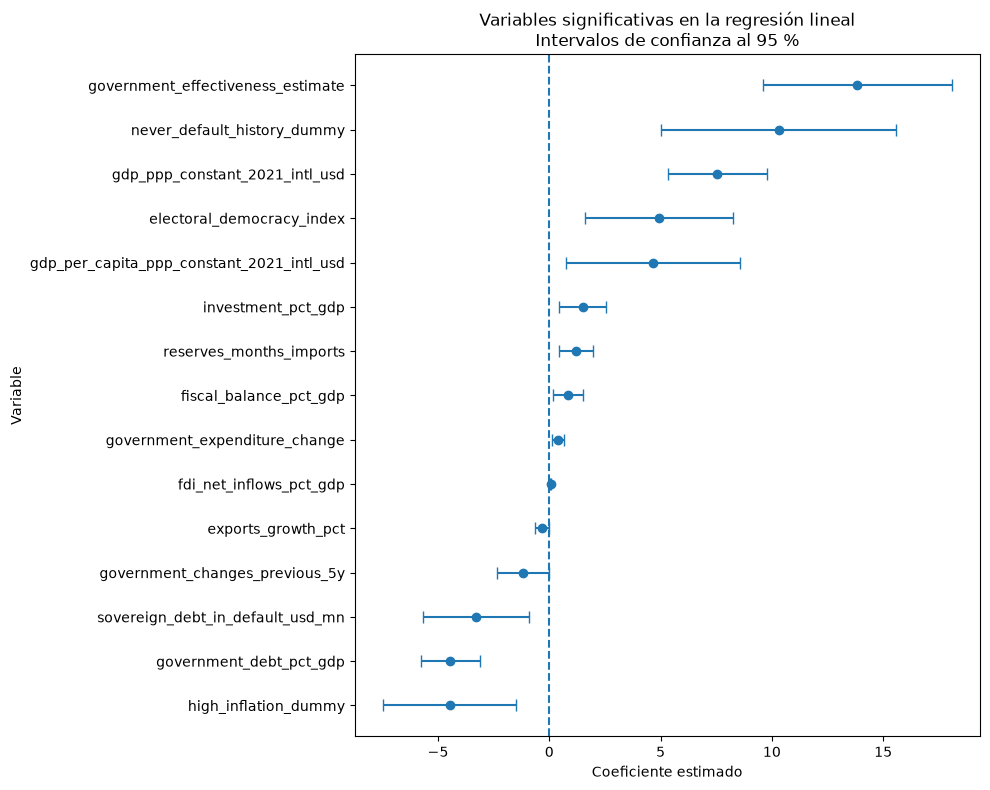

In [90]:
# Variables significativas al 5 %

significant_variables = (
    linear_significance_OLS[
        linear_significance_OLS["p_value"] < 0.05
    ]
    .sort_values("coefficient")
    .copy()
)

# Error inferior y superior del intervalo de confianza

error_lower = (
    significant_variables["coefficient"]
    - significant_variables["ci_lower"]
)

error_upper = (
    significant_variables["ci_upper"]
    - significant_variables["coefficient"]
)

plt.figure(figsize=(10, 8))

plt.errorbar(
    significant_variables["coefficient"],
    significant_variables["variable"],
    xerr=[
        error_lower,
        error_upper
    ],
    fmt="o",
    capsize=4
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Coeficiente estimado")
plt.ylabel("Variable")
plt.title(
    "Variables significativas en la regresión lineal\n"
    "Intervalos de confianza al 95 %"
)

plt.tight_layout()
plt.show()

Tras el análisis de multicolinealidad se obtuvo una especificación reducida de la regresión lineal sin dependencias lineales exactas y con todos los factores de inflación de la varianza por debajo de 10. La depuración reduce considerablemente la redundancia entre las variables y permite realizar una interpretación más fiable de los coeficientes y de su significancia estadística.

La regresión estimada sobre el conjunto de entrenamiento alcanza un (R^2) de 0,862 y un (R^2) ajustado de 0,858. De las 57 variables incluidas en la especificación final, 15 presentan significancia estadística al 5 %, 11 al 1 % y 5 al 0,1 %, utilizando errores estándar robustos agrupados por país.

Entre las variables con una asociación positiva y estadísticamente significativa con la calificación crediticia destacan el PIB ajustado por paridad de poder adquisitivo, el PIB per cápita PPA, la efectividad gubernamental, la inversión, las reservas internacionales, el saldo fiscal y el índice de democracia electoral. Asimismo, los países sin antecedentes históricos de default presentan, manteniendo constantes el resto de factores, una calificación esperada superior.

En sentido contrario, la deuda pública sobre el PIB, la existencia de deuda soberana en situación de default y los episodios de inflación elevada presentan coeficientes negativos y estadísticamente significativos. Estos resultados son coherentes con la hipótesis de que una mayor vulnerabilidad fiscal, un historial crediticio desfavorable y episodios de inestabilidad macroeconómica se relacionan con una menor calidad crediticia soberana.

La efectividad gubernamental destaca especialmente dentro del bloque institucional, mientras que el tamaño económico, el nivel de desarrollo y la deuda pública aparecen como variables relevantes dentro de los bloques macroeconómico y fiscal. En conjunto, los resultados sugieren que la calificación soberana no depende exclusivamente de la situación fiscal de un país, sino de una combinación de capacidad económica, fortaleza institucional, posición externa y antecedentes crediticios.

No obstante, los coeficientes deben interpretarse como asociaciones parciales y no como relaciones causales. Asimismo, algunas variables presentan signos menos intuitivos una vez se controla simultáneamente por el resto de predictores, por lo que su interpretación individual debe realizarse con cautela.


---
Entre las variables con mayor relevancia estadística destaca la **efectividad del gobierno**, con un coeficiente positivo de 13,84 y un nivel de significancia inferior al 0,1 % ((p<0,001)), lo que muestra una fuerte asociación positiva entre la calidad de la actuación gubernamental y la calificación crediticia soberana. También presentan una relación positiva y altamente significativa el **PIB en paridad de poder adquisitivo** ((\beta=7,56); (p<0,001)) y la ausencia de antecedentes históricos de default, representada mediante la variable `never_default_history_dummy` ((\beta=10,30); (p<0,001)).

En sentido contrario, la **deuda pública sobre el PIB** presenta uno de los efectos negativos más relevantes ((\beta=-4,44); (p<0,001)), indicando que, manteniendo constantes el resto de factores, mayores niveles de endeudamiento público se asocian con una menor calificación soberana. La cantidad de **deuda soberana en situación de default** también presenta una asociación negativa y significativa (($\beta=-3,29$); ($p=0,007$)). Del mismo modo, los episodios de **inflación elevada** se relacionan con una reducción de la calificación esperada (($\beta=-4,48$); ($p=0,003$)), mientras que el nivel ordinario de inflación no resulta estadísticamente significativo, lo que sugiere que podría ser especialmente relevante la aparición de episodios inflacionarios intensos.

Dentro del bloque externo, las **reservas internacionales medidas en meses de importaciones** presentan un coeficiente positivo de 1,19 (($p=0,002$)), reflejando la importancia de disponer de un mayor colchón de liquidez externa. En el ámbito fiscal, un mayor **saldo fiscal** se asocia positivamente con el rating (($\beta=0,83$); ($p=0,016$)). También resultan significativos el **PIB per cápita ajustado por PPA** (($\beta=4,66$); ($p=0,019$)), la **inversión como porcentaje del PIB** (($\beta=1,50); (p=0,005$)) y el **índice de democracia electoral** (($\beta=4,92); (p=0,004$)).

Por último, el número de **cambios de gobierno durante los cinco años anteriores** presenta una asociación negativa y significativa (($\beta=-1,19$); ($p=0,047$)), lo que puede reflejar que una mayor inestabilidad política se relaciona con una menor calidad crediticia. El crecimiento de las exportaciones también presenta un coeficiente negativo y significativo ((\beta=-0,32); (p=0,034)); no obstante, este resultado debe interpretarse con cautela, ya que los coeficientes representan efectos parciales condicionados al resto de variables incluidas en el modelo y no implican necesariamente una relación causal directa.


In [103]:
linear_validation_results_OLS = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

linear_validation_results_OLS[
    "rating_year"
] = (
    linear_validation_results_OLS["year"] + 1
)

linear_validation_results_OLS[
    "prediction"
] = linear_validation_pred_OLS

linear_validation_results_OLS[
    "residual"
] = (
    linear_validation_results_OLS["rating_score_mean_t1"]
    - linear_validation_results_OLS["prediction"]
)

linear_validation_results_OLS[
    "absolute_error"
] = (
    linear_validation_results_OLS["residual"].abs()
)

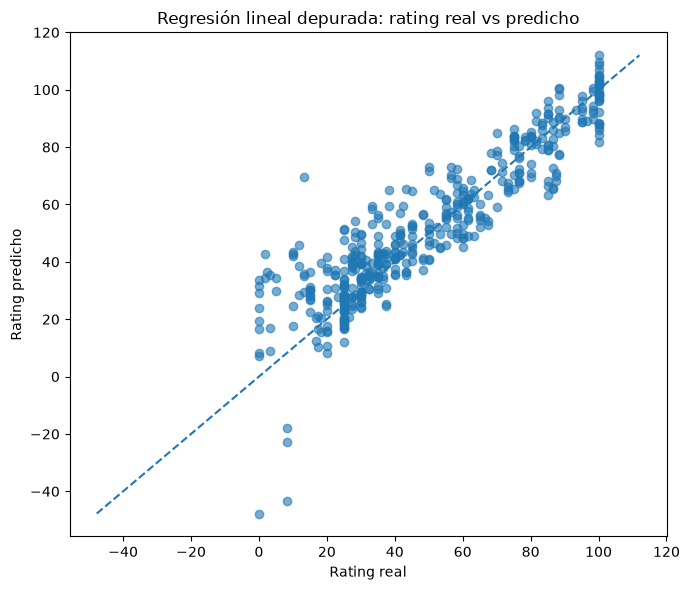

In [92]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_validation,
    linear_validation_pred_OLS,
    alpha=0.6
)

min_value = min(
    y_validation.min(),
    linear_validation_pred_OLS.min()
)

max_value = max(
    y_validation.max(),
    linear_validation_pred_OLS.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")

plt.title(
    "Regresión lineal depurada: rating real vs predicho"
)

plt.tight_layout()
plt.show()

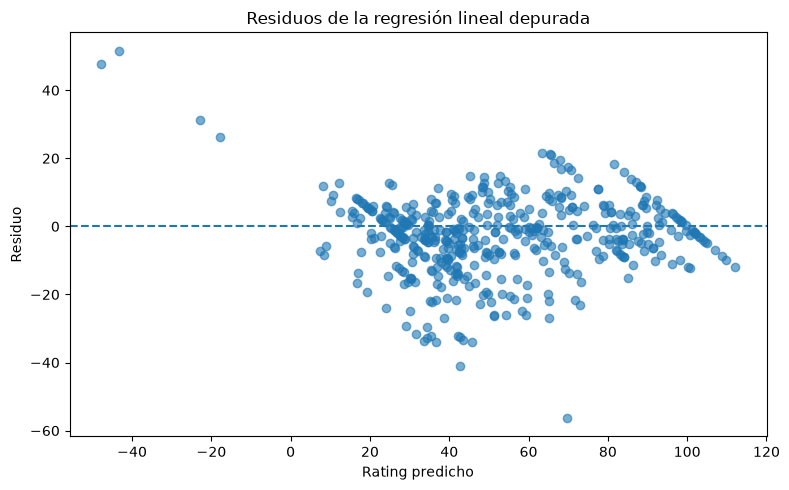

In [93]:
linear_residuals_OLS = (
    y_validation.to_numpy()
    - linear_validation_pred_OLS
)

plt.figure(figsize=(8, 5))

plt.scatter(
    linear_validation_pred_OLS,
    linear_residuals_OLS,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Rating predicho")
plt.ylabel("Residuo")

plt.title(
    "Residuos de la regresión lineal depurada"
)

plt.tight_layout()
plt.show()

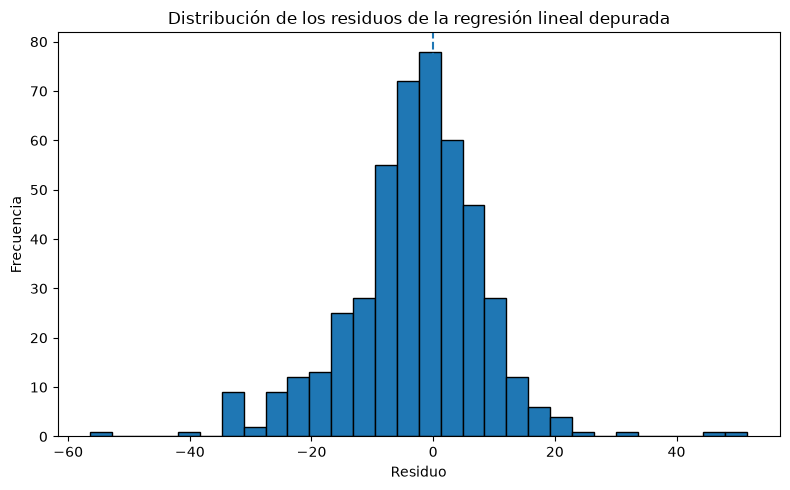

In [94]:
plt.figure(figsize=(8, 5))

plt.hist(
    linear_residuals_OLS,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de los residuos de la regresión lineal depurada"
)

plt.tight_layout()
plt.show()

In [95]:
linear_error_by_year_OLS = (
    linear_validation_results_OLS
    .groupby("year")["absolute_error"]
    .mean()
)

display(
    linear_error_by_year_OLS.round(3)
)

year
2019    8.651
2020    7.804
2021    9.001
Name: absolute_error, dtype: float64

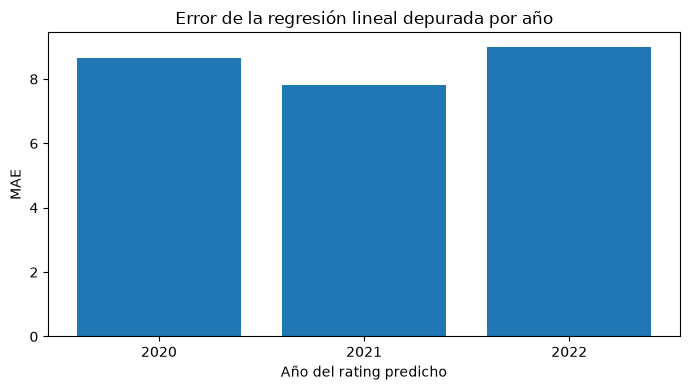

In [98]:
linear_error_by_rating_year_OLS = (
    linear_validation_results_OLS
    .groupby("rating_year")["absolute_error"]
    .mean()
)

plt.figure(figsize=(7, 4))

plt.bar(
    linear_error_by_rating_year_OLS.index.astype(str),
    linear_error_by_rating_year_OLS.values
)

plt.xlabel("Año del rating predicho")
plt.ylabel("MAE")

plt.title(
    "Error de la regresión lineal depurada por año"
)

plt.tight_layout()
plt.show()

In [99]:
worst_linear_predictions_OLS = (
    linear_validation_results_OLS
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_linear_predictions_OLS[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,69.67,56.33
3379,"Venezuela, RB",2020,2021,8.33,-43.28,51.61
1845,Lebanon,2021,2022,0.00,-47.75,47.75
409,Belarus,2021,2022,1.67,42.69,41.02
3278,Ukraine,2021,2022,11.67,45.77,34.10
1229,Ghana,2021,2022,2.50,36.53,34.03
2655,Puerto Rico (US),2019,2020,0.00,33.73,33.73
3147,Turkmenistan,2019,2020,10.00,43.47,33.47
1908,Sri Lanka,2021,2022,1.67,34.33,32.66
3148,Turkmenistan,2020,2021,10.00,42.64,32.64


In [100]:
outside_scale_OLS = (
    (linear_validation_pred_OLS < 0)
    |
    (linear_validation_pred_OLS > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_scale_OLS.sum()
)

print(
    "Porcentaje:",
    round(
        outside_scale_OLS.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    linear_validation_pred_OLS.min()
)

print(
    "Predicción máxima:",
    linear_validation_pred_OLS.max()
)

Predicciones fuera de 0-100: 21
Porcentaje: 4.51 %
Predicción mínima: -47.748655416105215
Predicción máxima: 112.01752047966717


El análisis de las observaciones con mayor error absoluto muestra que las mayores desviaciones de la regresión lineal depurada se concentran en determinados países sometidos a situaciones económicas, financieras o geopolíticas especialmente adversas.

Resulta especialmente relevante la presencia de Rusia, Bielorrusia y Ucrania entre los mayores errores correspondientes a la predicción de las calificaciones de 2022 a partir de información observada en 2021. También aparecen economías como Líbano y Sri Lanka, caracterizadas durante este periodo por episodios de elevada inestabilidad económica y financiera.

Estos resultados reflejan una de las principales limitaciones de un modelo basado exclusivamente en variables fundamentales observadas en el año anterior: determinados shocks o cambios abruptos de la situación crediticia pueden producirse después del momento en el que se observan las variables explicativas y, por tanto, resultar difíciles de anticipar.

Asimismo, los mayores errores se concentran principalmente en países con calificaciones muy reducidas. En algunos de estos casos la regresión genera incluso predicciones negativas, lo que vuelve a poner de manifiesto que el modelo lineal no impone las restricciones naturales de la escala de calificación 0-100.

Por tanto, aunque la regresión reproduce adecuadamente la estructura general de las calificaciones soberanas, presenta mayores dificultades para representar episodios extremos y deterioros crediticios bruscos.


In [104]:
comparison_linear_versions = pd.DataFrame({
    "Regresión original": linear_results,
    "Regresión depurada": linear_results_OLS
}).T

display(
    comparison_linear_versions.round(3)
)

,MAE,RMSE,R2
Regresión original,7.261,10.456,0.859
Regresión depurada,8.486,11.760,0.821


In [105]:
train_rating_available = (
    train["rating_score_mean_t"].notna()
)

validation_rating_available = (
    validation["rating_score_mean_t"].notna()
)

print(
    "Entrenamiento total:",
    len(train)
)

print(
    "Entrenamiento con rating_t:",
    train_rating_available.sum()
)

print(
    "Validación total:",
    len(validation)
)

print(
    "Validación con rating_t:",
    validation_rating_available.sum()
)

Entrenamiento total: 2497
Entrenamiento con rating_t: 2440
Validación total: 466
Validación con rating_t: 464


In [106]:
from sklearn.preprocessing import StandardScaler

# Índices con rating previo disponible

train_rating_index = train[
    train_rating_available
].index

validation_rating_index = validation[
    validation_rating_available
].index

# Fundamentales

X_train_OLS_rating = (
    X_train_OLS
    .loc[train_rating_index]
    .copy()
)

X_validation_OLS_rating = (
    X_validation_OLS
    .loc[validation_rating_index]
    .copy()
)

# Objetivo

y_train_rating = y_train.loc[
    train_rating_index
]

y_validation_rating = y_validation.loc[
    validation_rating_index
]

# Escalar rating_t usando solamente entrenamiento

rating_scaler = StandardScaler()

X_train_OLS_rating[
    "rating_score_mean_t"
] = rating_scaler.fit_transform(
    train.loc[
        train_rating_index,
        ["rating_score_mean_t"]
    ]
).ravel()

X_validation_OLS_rating[
    "rating_score_mean_t"
] = rating_scaler.transform(
    validation.loc[
        validation_rating_index,
        ["rating_score_mean_t"]
    ]
).ravel()

print(
    "Train:",
    X_train_OLS_rating.shape
)

print(
    "Validation:",
    X_validation_OLS_rating.shape
)

Train: (2440, 58)
Validation: (464, 58)


In [107]:
linear_model_rating = LinearRegression()

linear_model_rating.fit(
    X_train_OLS_rating,
    y_train_rating
)

linear_validation_pred_rating = (
    linear_model_rating.predict(
        X_validation_OLS_rating
    )
)

linear_results_rating = evaluate_model(
    y_validation_rating,
    linear_validation_pred_rating
)

display(
    pd.DataFrame(
        [linear_results_rating],
        index=[
            "Fundamentales + rating_t"
        ]
    ).round(3)
)

,MAE,RMSE,R2
Fundamentales + rating_t,2.402,4.52,0.974


In [108]:
# Regresión depurada solo con fundamentales
# sobre las mismas 464 observaciones

linear_OLS_common_pred = (
    pd.Series(
        linear_validation_pred_OLS,
        index=validation.index
    )
    .loc[validation_rating_index]
)

# Persistencia

persistence_common_pred = validation.loc[
    validation_rating_index,
    "rating_score_mean_t"
]

# Media de entrenamiento

mean_common_pred = np.full(
    len(validation_rating_index),
    y_train.mean()
)

comparison_rating_model = pd.DataFrame({
    "Media": evaluate_model(
        y_validation_rating,
        mean_common_pred
    ),
    
    "Persistencia": evaluate_model(
        y_validation_rating,
        persistence_common_pred
    ),
    
    "Fundamentales": evaluate_model(
        y_validation_rating,
        linear_OLS_common_pred
    ),
    
    "Fundamentales + rating_t": evaluate_model(
        y_validation_rating,
        linear_validation_pred_rating
    )
}).T

display(
    comparison_rating_model.round(3)
)

,MAE,RMSE,R2
Media,25.223,28.717,-0.066
Persistencia,1.505,4.209,0.977
Fundamentales,8.478,11.761,0.821
Fundamentales + rating_t,2.402,4.520,0.974


La incorporación de la calificación crediticia vigente en el año (t) produce una mejora muy notable en la capacidad predictiva de la regresión lineal. El MAE disminuye desde 8,478 puntos cuando se utilizan exclusivamente variables fundamentales hasta 2,402 puntos al incorporar el rating previo, mientras que el (R^2) aumenta de 0,821 a 0,974.

Este resultado confirma la elevada persistencia temporal de las calificaciones crediticias soberanas. Sin embargo, la regresión que combina fundamentales y rating previo no consigue superar al baseline de persistencia, que alcanza un MAE de 1,505 y un (R^2) de 0,977. Por tanto, en una especificación estrictamente lineal, la incorporación simultánea de los fundamentales no aporta suficiente información adicional como para mejorar la predicción obtenida simplemente manteniendo la calificación del año anterior.

Este resultado no implica que las variables fundamentales carezcan de capacidad explicativa. La regresión estimada exclusivamente con estas variables presenta un (R^2) de 0,821 en la muestra común de validación, mostrando que explican una parte considerable de las diferencias de calidad crediticia entre países. No obstante, una vez conocida la calificación vigente, su elevada estabilidad interanual domina la predicción a un horizonte de un año.

Este resultado constituye además una referencia especialmente exigente para los modelos posteriores. Los métodos regularizados y no lineales deberán demostrar si son capaces de extraer de los fundamentales información adicional que permita anticipar modificaciones de la calificación y superar el baseline de persistencia.


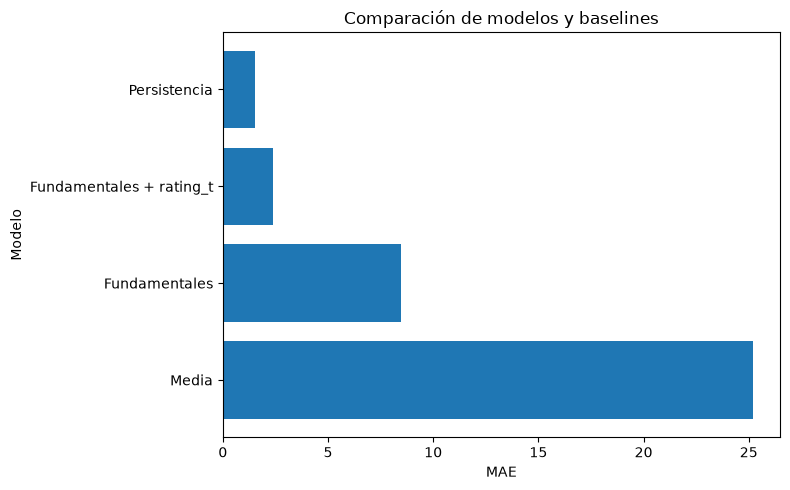

In [109]:
model_comparison_plot = (
    comparison_rating_model
    .sort_values("MAE", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    model_comparison_plot.index,
    model_comparison_plot["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("Modelo")

plt.title(
    "Comparación de modelos y baselines"
)

plt.tight_layout()
plt.show()

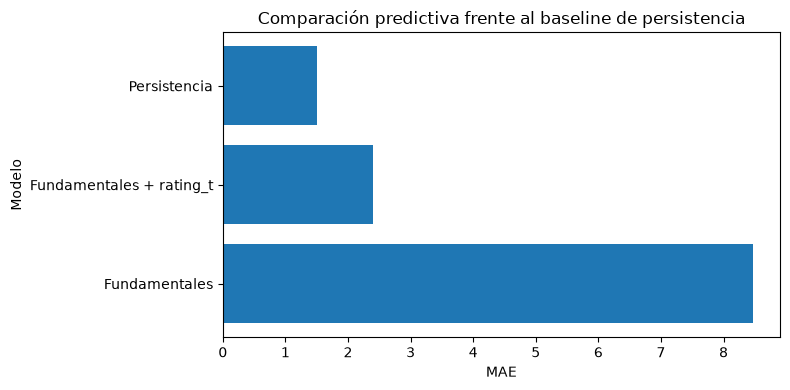

In [110]:
comparison_without_mean = (
    comparison_rating_model
    .drop(index="Media")
    .sort_values("MAE", ascending=False)
)

plt.figure(figsize=(8, 4))

plt.barh(
    comparison_without_mean.index,
    comparison_without_mean["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("Modelo")

plt.title(
    "Comparación predictiva frente al baseline de persistencia"
)

plt.tight_layout()
plt.show()

In [111]:
# Cambio real entre t y t+1

validation_common = validation[
    validation["rating_score_mean_t"].notna()
].copy()

validation_common["rating_change_t1"] = (
    validation_common["rating_score_mean_t1"]
    - validation_common["rating_score_mean_t"]
)

validation_common["rating_changed_t1"] = (
    validation_common["rating_change_t1"] != 0
)

print(
    "Observaciones:",
    len(validation_common)
)

print(
    "Sin cambio:",
    (~validation_common["rating_changed_t1"]).sum()
)

print(
    "Con cambio:",
    validation_common["rating_changed_t1"].sum()
)

print(
    "Porcentaje con cambio:",
    round(
        validation_common["rating_changed_t1"].mean() * 100,
        2
    ),
    "%"
)

Observaciones: 464
Sin cambio: 327
Con cambio: 137
Porcentaje con cambio: 29.53 %


In [112]:
changed_validation = validation_common[
    validation_common["rating_changed_t1"]
].copy()

persistence_changed_results = evaluate_model(
    changed_validation["rating_score_mean_t1"],
    changed_validation["rating_score_mean_t"]
)

display(
    pd.DataFrame(
        [persistence_changed_results],
        index=["Persistencia - solo cambios"]
    ).round(3)
)

,MAE,RMSE,R2
Persistencia - solo cambios,5.097,7.746,0.897


In [113]:
rating_predictions = pd.Series(
    linear_validation_pred_rating,
    index=validation_rating_index
)

changed_index = changed_validation.index

comparison_changed = pd.DataFrame({
    "Persistencia": evaluate_model(
        changed_validation["rating_score_mean_t1"],
        changed_validation["rating_score_mean_t"]
    ),
    
    "Fundamentales + rating_t": evaluate_model(
        changed_validation["rating_score_mean_t1"],
        rating_predictions.loc[changed_index]
    )
}).T

display(
    comparison_changed.round(3)
)

,MAE,RMSE,R2
Persistencia,5.097,7.746,0.897
Fundamentales + rating_t,4.951,7.736,0.897


La persistencia funciona extraordinariamente bien en la muestra completa porque una gran parte de las calificaciones permanece sin cambios. Sin embargo, cuando el análisis se restringe a las observaciones en las que efectivamente se produce una modificación del rating, la regresión que combina fundamentales y calificación previa obtiene un MAE ligeramente inferior. Esto sugiere que las variables fundamentales contienen cierta información adicional sobre los cambios futuros de la calidad crediticia, aunque una especificación estrictamente lineal todavía presenta una capacidad limitada para explotarla.

In [114]:
X_vif_rating = sm.add_constant(
    X_train_OLS_rating,
    has_constant="add"
)

vif_rating = pd.DataFrame({
    "variable": X_vif_rating.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_rating.values,
            i
        )
        for i in range(X_vif_rating.shape[1])
    ]
})

vif_rating = (
    vif_rating[
        vif_rating["variable"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "VIF >= 10:",
    (vif_rating["VIF"] >= 10).sum()
)

print(
    "VIF entre 5 y 10:",
    (
        (vif_rating["VIF"] >= 5)
        &
        (vif_rating["VIF"] < 10)
    ).sum()
)

display(
    vif_rating.head(20)
)

VIF >= 10: 0
VIF entre 5 y 10: 6


,variable,VIF
0,rating_score_mean_t,7.454588
1,default_previous_10y,6.940289
2,government_effectiveness_estimate,6.397123
3,gdp_per_capita_ppp_constant_2021_intl_usd,6.138827
4,never_default_history_dummy,5.157944
5,default_previous_5y,5.069271
6,region_Europe & Central Asia,4.605805
7,current_account_balance_pct_gdp,4.416182
8,head_of_government_tenure_years,4.247115
9,political_stability_estimate,4.241327


In [115]:
X_train_stats_rating = sm.add_constant(
    X_train_OLS_rating,
    has_constant="add"
)

train_groups_rating = train.loc[
    train_rating_index,
    "iso3"
]

linear_stats_rating = sm.OLS(
    y_train_rating,
    X_train_stats_rating
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train_groups_rating
    }
)

print(
    linear_stats_rating.summary()
)

                             OLS Regression Results                             
Dep. Variable:     rating_score_mean_t1   R-squared:                       0.984
Model:                              OLS   Adj. R-squared:                  0.983
Method:                   Least Squares   F-statistic:                     9154.
Date:                  Tue, 18 Aug 2026   Prob (F-statistic):          2.79e-243
Time:                          12:08:11   Log-Likelihood:                -6450.9
No. Observations:                  2440   AIC:                         1.302e+04
Df Residuals:                      2381   BIC:                         1.336e+04
Df Model:                            58                                         
Covariance Type:                cluster                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [116]:
linear_significance_rating = pd.DataFrame({
    "variable": linear_stats_rating.params.index,
    "coefficient": linear_stats_rating.params.values,
    "std_error": linear_stats_rating.bse.values,
    "statistic": linear_stats_rating.tvalues.values,
    "p_value": linear_stats_rating.pvalues.values,
    "ci_lower": linear_stats_rating.conf_int()[0].values,
    "ci_upper": linear_stats_rating.conf_int()[1].values
})

linear_significance_rating = linear_significance_rating[
    linear_significance_rating["variable"] != "const"
].copy()

linear_significance_rating["significance"] = (
    linear_significance_rating["p_value"]
    .apply(significance_stars)
)

linear_significance_rating = (
    linear_significance_rating
    .sort_values("p_value")
    .reset_index(drop=True)
)

display(
    linear_significance_rating[
        [
            "variable",
            "coefficient",
            "std_error",
            "statistic",
            "p_value",
            "significance"
        ]
    ]
    .head(30)
    .round(4)
)

,variable,coefficient,std_error,statistic,p_value,significance
0,rating_score_mean_t,25.2221,0.2313,109.0357,0.0000,***
1,government_debt_pct_gdp,-0.3968,0.1001,-3.9630,0.0001,***
2,government_effectiveness_estimate,1.0146,0.2845,3.5657,0.0004,***
3,gdp_ppp_constant_2021_intl_usd,0.5617,0.1620,3.4680,0.0005,***
4,real_interest_rate_5y_mean,0.0450,0.0137,3.2919,0.0010,***
5,exports_growth_3y_std,-0.2315,0.0791,-2.9279,0.0034,**
6,current_account_balance_pct_gdp,0.3249,0.1129,2.8778,0.0040,**
7,inflation_cpi_pct,-0.1724,0.0601,-2.8662,0.0042,**
8,primary_deficit_dummy,-0.4700,0.1651,-2.8475,0.0044,**
9,fragile_states_index,0.2891,0.1075,2.6888,0.0072,**


In [117]:
print(
    "Variables significativas al 5 %:",
    (linear_significance_rating["p_value"] < 0.05).sum()
)

print(
    "Variables significativas al 1 %:",
    (linear_significance_rating["p_value"] < 0.01).sum()
)

print(
    "Variables significativas al 0,1 %:",
    (linear_significance_rating["p_value"] < 0.001).sum()
)

Variables significativas al 5 %: 21
Variables significativas al 1 %: 11
Variables significativas al 0,1 %: 5


In [118]:
display(
    linear_significance_rating[
        linear_significance_rating["variable"]
        == "rating_score_mean_t"
    ].round(4)
)

,variable,coefficient,std_error,statistic,p_value,ci_lower,ci_upper,significance
0,rating_score_mean_t,25.2221,0.2313,109.0357,0.0,24.7687,25.6755,***


In [119]:
rating_sd_train = rating_scaler.scale_[0]

rating_coefficient_standardized = (
    linear_significance_rating.loc[
        linear_significance_rating["variable"]
        == "rating_score_mean_t",
        "coefficient"
    ].iloc[0]
)

rating_coefficient_original = (
    rating_coefficient_standardized
    / rating_sd_train
)

print(
    "Desviación estándar de rating_t:",
    round(rating_sd_train, 4)
)

print(
    "Coeficiente equivalente en escala original:",
    round(rating_coefficient_original, 4)
)

Desviación estándar de rating_t: 26.5263
Coeficiente equivalente en escala original: 0.9508


La calificación crediticia del año anterior presenta una asociación especialmente elevada con la calificación del año siguiente. Su coeficiente estimado es 25,22 y resulta altamente significativo ((p<0,001)), incluso utilizando errores estándar robustos agrupados por país.

Dado que esta variable ha sido estandarizada antes de la estimación, el coeficiente indica que un incremento de una desviación estándar en la calificación vigente se asocia, manteniendo constantes el resto de factores, con un aumento aproximado de 25,22 puntos en la calificación del año siguiente.

Este resultado confirma cuantitativamente la elevada persistencia temporal de las calificaciones soberanas observada previamente mediante el baseline de persistencia. No obstante, la inclusión del rating previo no elimina necesariamente la capacidad informativa de los fundamentales. Por ello, resulta especialmente relevante analizar qué variables económicas, fiscales, externas e institucionales mantienen significancia estadística una vez controlado el nivel de calificación de partida.


**Variables especialmente destacables**

`government_debt_pct_gdp` sigue siendo muy significativa y negativa: $β=−0.397,p<0.001$

Incluso conociendo el rating actual, una mayor deuda pública sigue asociándose con una peor calificación futura.

`government_effectiveness_estimate` también sobrevive con: $β=1.015,p<0.001$

Esto parece especialmente potente: la calidad institucional no sirve únicamente para explicar por qué un país tiene un rating estructuralmente alto, sino que mantiene información adicional una vez controlamos por su rating actual.

También continúa siendo relevante el tamaño de la economía: $GDP_{PPP}:β=0.562, p<0.001$

Y aparecen variables dinámicas muy interesantes:

`government_debt_change<0`, 
`government_debt_3y_change<0`

Es decir, no solo importa cuánto debe el país, sino también si la deuda está creciendo.

Algo parecido ocurre con la inflación. Ahora `inflation_cpi_pct` tiene signo negativo y es significativa: $β=−0.172,p=0.004$, mientras que también aparece `inflation_3y_std`. Esto sugiere que tanto el nivel como la inestabilidad de precios contienen información adicional.


---

La incorporación de la calificación crediticia del año anterior modifica de forma notable la estructura de los factores estadísticamente relevantes. Aunque el rating vigente constituye, con diferencia, el principal predictor de la calificación futura, distintas variables fundamentales mantienen capacidad explicativa una vez controlado el nivel de partida.

Entre las variables que conservan una asociación estadísticamente significativa destacan la deuda pública, la efectividad gubernamental y el tamaño de la economía medido mediante PIB ajustado por paridad de poder adquisitivo. En particular, una mayor deuda pública continúa asociándose negativamente con la calificación futura, mientras que una mayor efectividad gubernamental y un mayor tamaño económico mantienen una relación positiva.

Resulta especialmente relevante la aparición de diferentes variables dinámicas. Tanto la variación anual como la variación acumulada a tres años de la deuda pública presentan coeficientes negativos y significativos. Asimismo, aparecen como relevantes el nivel y la volatilidad de la inflación, la volatilidad del crecimiento de las exportaciones, el saldo por cuenta corriente y distintos indicadores relacionados con los tipos de interés.

Este cambio respecto a la regresión basada exclusivamente en fundamentales resulta coherente con la naturaleza del problema. Cuando no se conoce la calificación previa, las variables estructurales permiten explicar gran parte de las diferencias de calidad crediticia existentes entre países. Sin embargo, una vez incorporado el rating vigente, adquieren mayor importancia las variables relacionadas con la evolución reciente de los fundamentales, ya que pueden contener información sobre posibles modificaciones futuras de la calificación.

Por tanto, los resultados sugieren que el nivel del rating presenta una elevada persistencia temporal, pero que determinadas variaciones macroeconómicas, fiscales y externas contienen información adicional potencialmente útil para anticipar su evolución.


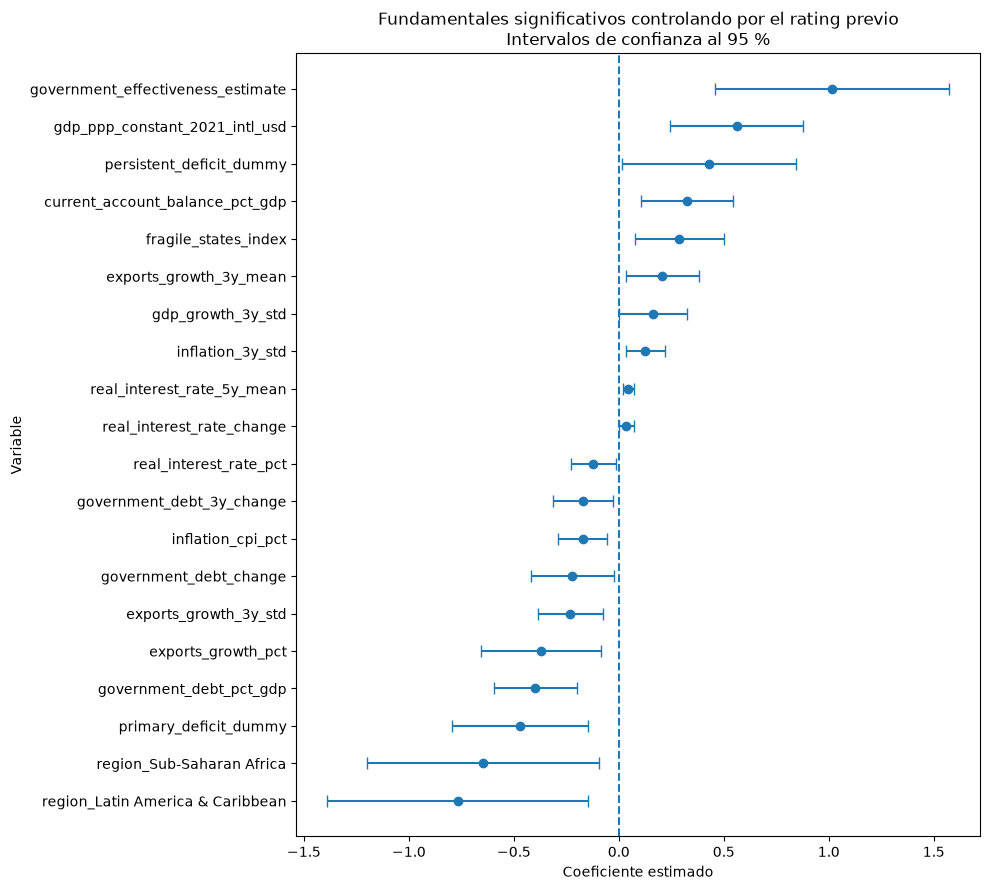

In [120]:
significant_fundamentals_rating = (
    linear_significance_rating[
        (linear_significance_rating["p_value"] < 0.05)
        &
        (
            linear_significance_rating["variable"]
            != "rating_score_mean_t"
        )
    ]
    .sort_values("coefficient")
    .copy()
)

error_lower = (
    significant_fundamentals_rating["coefficient"]
    - significant_fundamentals_rating["ci_lower"]
)

error_upper = (
    significant_fundamentals_rating["ci_upper"]
    - significant_fundamentals_rating["coefficient"]
)

plt.figure(figsize=(10, 9))

plt.errorbar(
    significant_fundamentals_rating["coefficient"],
    significant_fundamentals_rating["variable"],
    xerr=[
        error_lower,
        error_upper
    ],
    fmt="o",
    capsize=4
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Coeficiente estimado")
plt.ylabel("Variable")

plt.title(
    "Fundamentales significativos controlando por el rating previo\n"
    "Intervalos de confianza al 95 %"
)

plt.tight_layout()
plt.show()

In [121]:
significant_without_rating = set(
    linear_significance_OLS.loc[
        linear_significance_OLS["p_value"] < 0.05,
        "variable"
    ]
)

significant_with_rating = set(
    linear_significance_rating.loc[
        (
            linear_significance_rating["p_value"] < 0.05
        )
        &
        (
            linear_significance_rating["variable"]
            != "rating_score_mean_t"
        ),
        "variable"
    ]
)

significant_both = (
    significant_without_rating
    &
    significant_with_rating
)

only_without_rating = (
    significant_without_rating
    -
    significant_with_rating
)

only_with_rating = (
    significant_with_rating
    -
    significant_without_rating
)

print("Significativas en ambas regresiones:")
display(sorted(significant_both))

print("\nSolo significativas sin rating_t:")
display(sorted(only_without_rating))

print("\nSolo significativas controlando por rating_t:")
display(sorted(only_with_rating))

Significativas en ambas regresiones:


['exports_growth_pct',
 'gdp_ppp_constant_2021_intl_usd',
 'government_debt_pct_gdp',
 'government_effectiveness_estimate']


Solo significativas sin rating_t:


['electoral_democracy_index',
 'fdi_net_inflows_pct_gdp',
 'fiscal_balance_pct_gdp',
 'gdp_per_capita_ppp_constant_2021_intl_usd',
 'government_changes_previous_5y',
 'government_expenditure_change',
 'high_inflation_dummy',
 'investment_pct_gdp',
 'never_default_history_dummy',
 'reserves_months_imports',
 'sovereign_debt_in_default_usd_mn']


Solo significativas controlando por rating_t:


['current_account_balance_pct_gdp',
 'exports_growth_3y_mean',
 'exports_growth_3y_std',
 'fragile_states_index',
 'gdp_growth_3y_std',
 'government_debt_3y_change',
 'government_debt_change',
 'inflation_3y_std',
 'inflation_cpi_pct',
 'persistent_deficit_dummy',
 'primary_deficit_dummy',
 'real_interest_rate_5y_mean',
 'real_interest_rate_change',
 'real_interest_rate_pct',
 'region_Latin America & Caribbean',
 'region_Sub-Saharan Africa']

La comparación entre las dos especificaciones de la regresión lineal permite distinguir entre los factores relacionados principalmente con el nivel estructural de la calificación crediticia y aquellos que aportan información adicional sobre su evolución futura.

Cuatro variables resultan estadísticamente significativas tanto en la regresión basada exclusivamente en fundamentales como en la especificación que incorpora la calificación del año anterior: el PIB ajustado por paridad de poder adquisitivo, la deuda pública sobre el PIB, la efectividad gubernamental y el crecimiento de las exportaciones. La persistencia de estas variables en ambas especificaciones refuerza su relevancia dentro del análisis del riesgo soberano.

Por otra parte, determinadas variables pierden significancia cuando se incorpora el rating previo. Entre ellas se encuentran el PIB per cápita PPA, la inversión, las reservas internacionales, el saldo fiscal, la inversión extranjera directa, el historial de ausencia de default y el índice de democracia electoral. Este comportamiento sugiere que una parte de la información contenida en estas variables ya se encuentra reflejada en la calificación crediticia vigente. Por tanto, resultan especialmente útiles para explicar las diferencias estructurales de calidad crediticia entre países, pero presentan una menor capacidad incremental para anticipar el rating del año siguiente una vez conocida la situación de partida.

En cambio, al controlar por el rating vigente adquieren significancia diversas variables relacionadas con la evolución reciente de los fundamentales, entre ellas las variaciones de la deuda pública, la volatilidad del crecimiento y de la inflación, el saldo por cuenta corriente, diferentes medidas de los tipos de interés y la evolución de las exportaciones. Este resultado sugiere que, una vez conocido el nivel de calificación actual, las variables dinámicas pueden aportar más información que algunos indicadores puramente estructurales para anticipar modificaciones futuras de la calidad crediticia.

En conjunto, los resultados apuntan a una diferenciación entre factores de nivel y factores de cambio: las características estructurales ayudan a explicar dónde se sitúa un país dentro de la escala de rating, mientras que la evolución reciente de determinados indicadores macroeconómicos, fiscales y externos puede resultar más relevante para anticipar movimientos futuros de la calificación.


,Grupo,Número de variables
0,Significativas en ambas,4
1,Solo sin rating_t,11
2,Solo con rating_t,16


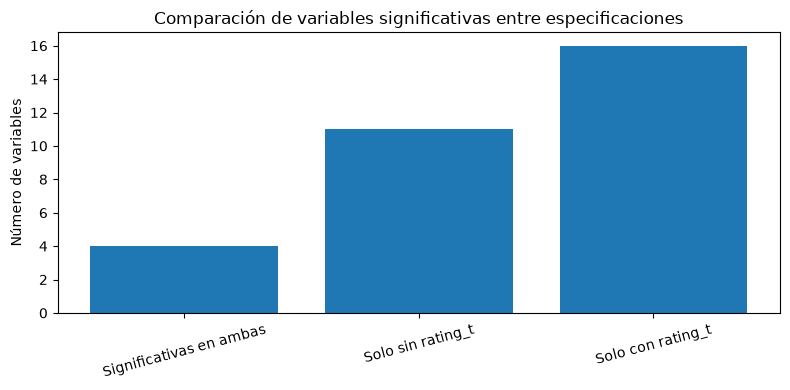

In [122]:
significance_comparison = pd.DataFrame({
    "Grupo": [
        "Significativas en ambas",
        "Solo sin rating_t",
        "Solo con rating_t"
    ],
    "Número de variables": [
        len(significant_both),
        len(only_without_rating),
        len(only_with_rating)
    ]
})

display(significance_comparison)

plt.figure(figsize=(8, 4))

plt.bar(
    significance_comparison["Grupo"],
    significance_comparison["Número de variables"]
)

plt.ylabel("Número de variables")
plt.title(
    "Comparación de variables significativas entre especificaciones"
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [123]:
max_length = max(
    len(significant_both),
    len(only_without_rating),
    len(only_with_rating)
)

comparison_significant_variables = pd.DataFrame({
    "Significativas en ambas":
        list(sorted(significant_both))
        + [None] * (
            max_length - len(significant_both)
        ),

    "Solo sin rating_t":
        list(sorted(only_without_rating))
        + [None] * (
            max_length - len(only_without_rating)
        ),

    "Solo con rating_t":
        list(sorted(only_with_rating))
        + [None] * (
            max_length - len(only_with_rating)
        )
})

display(comparison_significant_variables)

,Significativas en ambas,Solo sin rating_t,Solo con rating_t
0,exports_growth_pct,electoral_democracy_index,current_account_balance_pct_gdp
1,gdp_ppp_constant_2021_intl_usd,fdi_net_inflows_pct_gdp,exports_growth_3y_mean
2,government_debt_pct_gdp,fiscal_balance_pct_gdp,exports_growth_3y_std
3,government_effectiveness_estimate,gdp_per_capita_ppp_constant_2021_intl_usd,fragile_states_index
4,NaN,government_changes_previous_5y,gdp_growth_3y_std
5,NaN,government_expenditure_change,government_debt_3y_change
6,NaN,high_inflation_dummy,government_debt_change
7,NaN,investment_pct_gdp,inflation_3y_std
8,NaN,never_default_history_dummy,inflation_cpi_pct
9,NaN,reserves_months_imports,persistent_deficit_dummy


In [126]:
import joblib
from pathlib import Path

MODEL_DATA_PATH = Path("data/model")

MODEL_41_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_1_prepared_data.joblib"
)

data_41 = {
    "train": train,
    "validation": validation,
    "test": test,

    "y_train": y_train,
    "y_validation": y_validation,
    "y_test": y_test,

    "X_train_A": X_train_A,
    "X_validation_A": X_validation_A,
    "X_test_A": X_test_A,

    "X_train_A_reduced": X_train_A_reduced,
    "X_validation_A_reduced": X_validation_A_reduced,
    "X_test_A_reduced": X_test_A_reduced,

    "linear_results": linear_results,
    "linear_results_OLS": linear_results_OLS,
    "linear_results_rating": linear_results_rating,

    "comparison_rating_model": comparison_rating_model
}

joblib.dump(
    data_41,
    MODEL_41_FILE
)

print(
    "Archivo guardado:",
    MODEL_41_FILE
)

Archivo guardado: data\model\notebook_4_1_prepared_data.joblib


In [127]:
# Cargar lo que ya estaba guardado

data_41 = joblib.load(
    MODEL_41_FILE
)

# Añadir las matrices de la Rama B

data_41["X_train_B"] = X_train_B
data_41["X_validation_B"] = X_validation_B
data_41["X_test_B"] = X_test_B

# Volver a guardar

joblib.dump(
    data_41,
    MODEL_41_FILE
)

print(
    "Matrices de Rama B añadidas correctamente"
)

Matrices de Rama B añadidas correctamente


In [128]:
print(
    [
        key
        for key in data_41.keys()
        if "_B" in key
    ]
)

['X_train_B', 'X_validation_B', 'X_test_B']


In [129]:
print(X_train_B.shape)
print(X_validation_B.shape)
print(X_test_B.shape)

(2497, 143)
(466, 143)
(471, 143)
